# Task - PREPARE DATASET
Mount Google Drive, load the CSV file "/content/drive/MyDrive/Colab Notebooks/sentiment-analysis-training-data.csv" into a pandas DataFrame, and display the first few rows of the DataFrame.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Mount Google Drive

Hubungkan Google Drive ke sesi Colab saat ini.


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

## Load CSV File

Muat file CSV dari path yang ditentukan ke dalam pandas DataFrame.


In [3]:
import pandas as pd
try:
    df = pd.read_csv('https://github.com/erlanggadewasakti/Prinsip-Sains-Data/releases/download/prod/sa-psd-dataset.csv')
    print("Dataset berhasil dimuat.")
except FileNotFoundError:
    print("Error: File dataset tidak ditemukan. Pastikan path file sudah benar.")
except Exception as e:
    print(f"Terjadi error saat membaca file: {e}")

Dataset berhasil dimuat.


# Task - EDA
Perform a comprehensive sentiment analysis EDA on the "ecinstruct-sentiment-analysis-samples.csv" dataset, focusing on visualizations and insights. The analysis should include data loading and inspection, data preprocessing (extracting sentiment labels and cleaning input text), target distribution analysis (sentiment countplot), text statistics analysis (character length, word count, average word length with histograms and boxplots), content analysis (N-grams with bar plots), visual analysis (word clouds for all text and per sentiment category), and a summary of key insights. Use the required libraries: pandas, matplotlib.pyplot, seaborn, nltk, and wordcloud.

## Muat & Inspeksi Data

Muat data dari file CSV dan tampilkan informasi dasar seperti tipe data, beberapa baris pertama, dan jumlah nilai yang hilang.


In [4]:
display(df.head())
df.info()
print("\nJumlah nilai yang hilang per kolom:")
print(df.isnull().sum())

,output,input,options,task,split
0,A: very positive,This is the second Sigg I've had. The first la...,"[""A: very positive"", ""B: positive"", ""C: neutra...",Sentiment_Analysis,train
1,A: very positive,This was very good read. I really enjoyed the ...,"[""A: very positive"", ""B: positive"", ""C: neutra...",Sentiment_Analysis,train
2,E: very negative,Clock time would not set. Returned and receive...,"[""A: very positive"", ""B: positive"", ""C: neutra...",Sentiment_Analysis,train
3,B: positive,This is a very good mp3 player. I found it ve...,"[""A: very positive"", ""B: positive"", ""C: neutra...",Sentiment_Analysis,train
4,A: very positive,"Another Benchmade, another love story. GREAT P...","[""A: very positive"", ""B: positive"", ""C: neutra...",Sentiment_Analysis,train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   output   30000 non-null  object
 1   input    30000 non-null  object
 2   options  28000 non-null  object
 3   task     30000 non-null  object
 4   split    30000 non-null  object
dtypes: object(5)
memory usage: 1.1+ MB

Jumlah nilai yang hilang per kolom:
output        0
input         0
options    2000
task          0
split         0
dtype: int64


## Pra-pemrosesan Data

Buat kolom baru untuk label sentimen yang bersih dan teks input yang sudah dibersihkan (lowercase, tanpa tanda baca, tanpa angka).


In [5]:
import re

# Extract sentiment labels
df['sentiment'] = df['output'].str.replace(r'^[A-E]:\s*', '', regex=True)

# Clean the input text
df['cleaned_input'] = df['input'].str.lower()
# df['cleaned_input'] = df['cleaned_input'].str.replace(r'[^\w\s]', '', regex=True) # Remove punctuation
# df['cleaned_input'] = df['cleaned_input'].str.replace(r'\d+', '', regex=True) # Remove numbers

df['sentiment'] = df['sentiment'].map({'very positive' : 'positive', 'very negative' : 'negative','positive':'positive','negative':'negative','neutral':'neutral'})

# Display the first few rows with new columns
display(df[['output', 'sentiment', 'input', 'cleaned_input']].head())

,output,sentiment,input,cleaned_input
0,A: very positive,positive,This is the second Sigg I've had. The first la...,this is the second sigg i've had. the first la...
1,A: very positive,positive,This was very good read. I really enjoyed the ...,this was very good read. i really enjoyed the ...
2,E: very negative,negative,Clock time would not set. Returned and receive...,clock time would not set. returned and receive...
3,B: positive,positive,This is a very good mp3 player. I found it ve...,this is a very good mp3 player. i found it ve...
4,A: very positive,positive,"Another Benchmade, another love story. GREAT P...","another benchmade, another love story. great p..."


## Analisis Distribusi Sentimen

Visualisasikan distribusi sentimen menggunakan diagram batang dan laporkan ketidakseimbangan data jika ada.


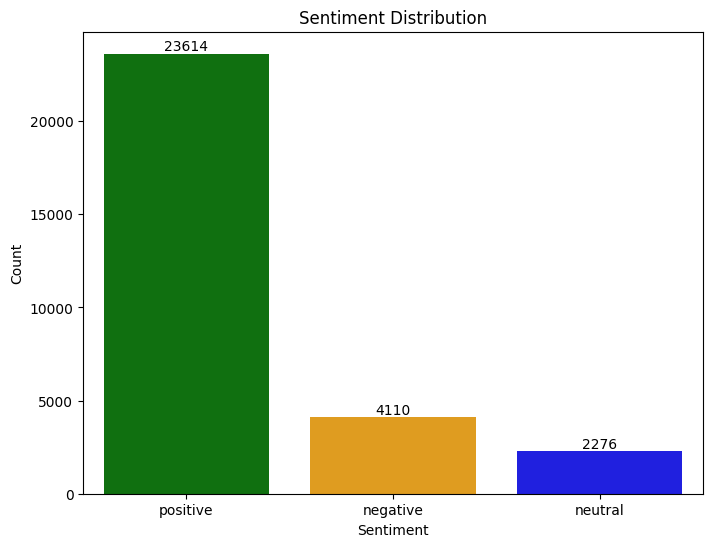

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sentiment_colors = {'positive': 'green', 'negative': 'orange', 'neutral': 'blue'}


plt.figure(figsize=(8, 6))
ax = sns.countplot(x='sentiment', data=df, hue='sentiment', palette=sentiment_colors, legend=False)

# Tambahkan keterangan angka di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## Analisis Statistik Teks

Hitung panjang karakter, jumlah kata, dan rata-rata panjang kata untuk setiap ulasan. Visualisasikan distribusi statistik teks ini menggunakan histogram dan boxplot berdasarkan sentimen.


In [7]:
df['char_length'] = df['cleaned_input'].str.len()
df['word_count'] = df['cleaned_input'].str.split().str.len()
df['avg_word_length'] = df['char_length'] / df['word_count']
df['avg_word_length'] = df['avg_word_length'].fillna(0) # Handle division by zero for empty strings

display(df[['cleaned_input', 'char_length', 'word_count', 'avg_word_length']].head())

,cleaned_input,char_length,word_count,avg_word_length
0,this is the second sigg i've had. the first la...,195,41,4.756098
1,this was very good read. i really enjoyed the ...,402,76,5.289474
2,clock time would not set. returned and receive...,176,31,5.677419
3,this is a very good mp3 player. i found it ve...,767,141,5.439716
4,"another benchmade, another love story. great p...",87,15,5.800000


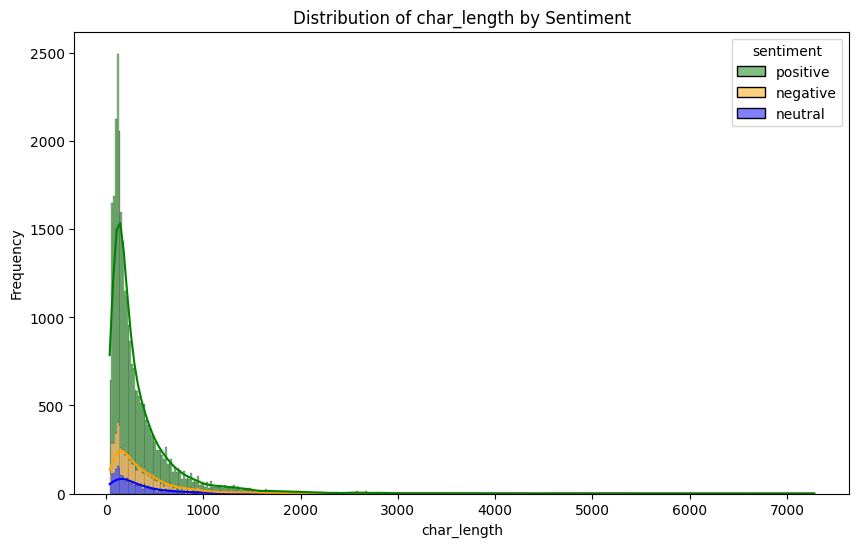

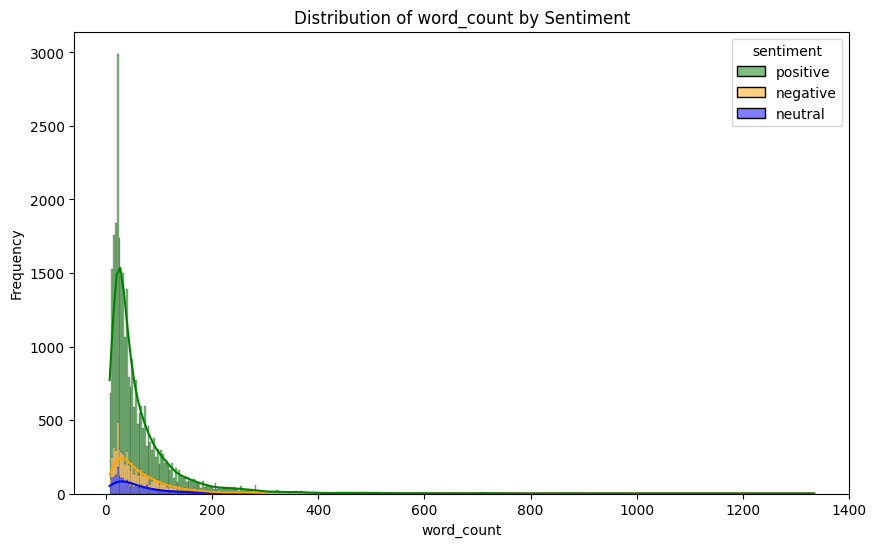

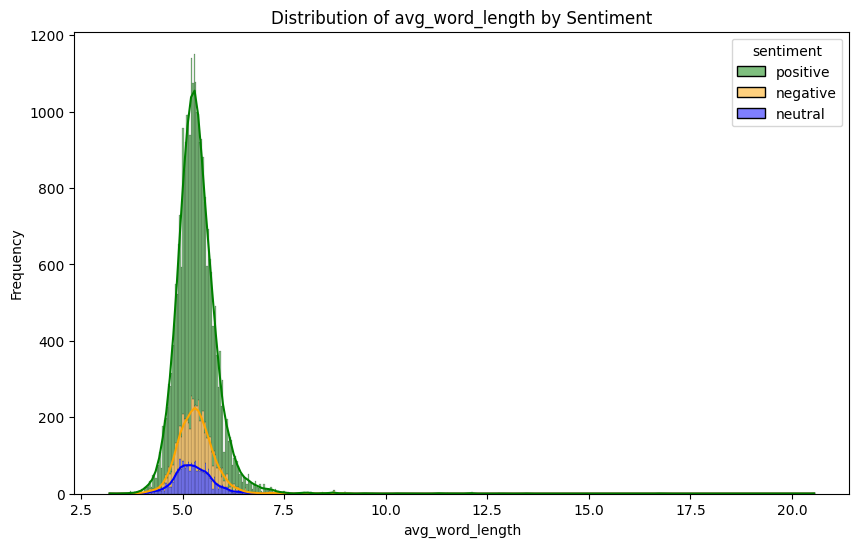

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for text statistics by sentiment
text_stats = ['char_length', 'word_count', 'avg_word_length']
for stat in text_stats:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=stat, hue='sentiment', kde=True, multiple='stack', palette=sentiment_colors)
    plt.title(f'Distribution of {stat} by Sentiment')
    plt.xlabel(stat)
    plt.ylabel('Frequency')
    plt.show()

/tmp/ipython-input-3609580337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y=stat,palette=sentiment_colors)


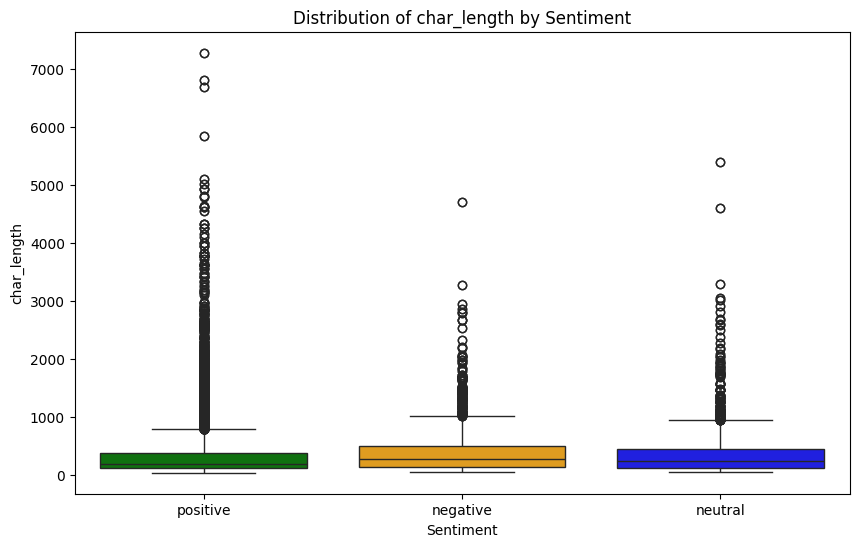

/tmp/ipython-input-3609580337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y=stat,palette=sentiment_colors)


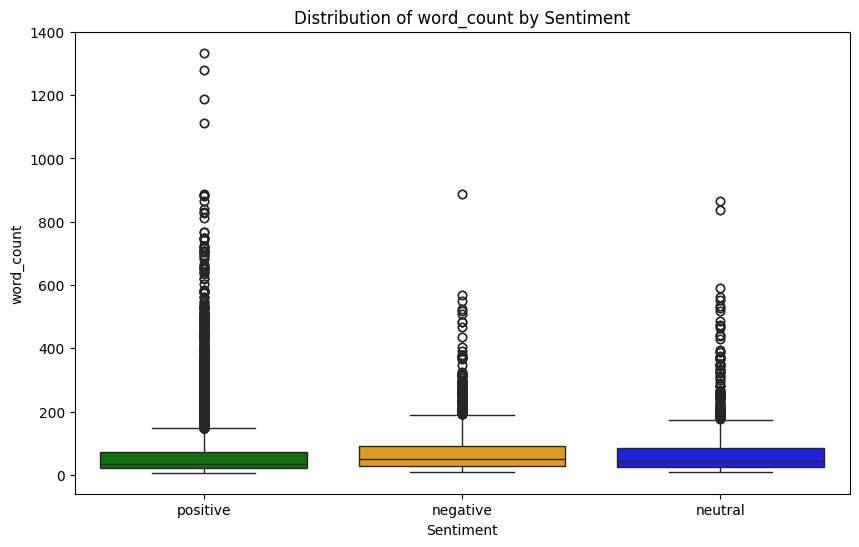

/tmp/ipython-input-3609580337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y=stat,palette=sentiment_colors)


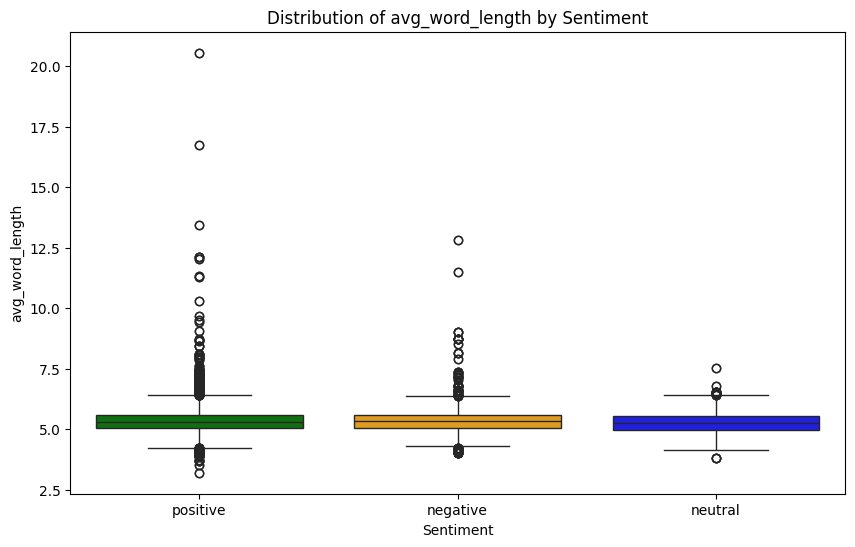

In [9]:
# Boxplots for text statistics by sentiment
text_stats = ['char_length', 'word_count', 'avg_word_length']
for stat in text_stats:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='sentiment', y=stat,palette=sentiment_colors)
    plt.title(f'Distribution of {stat} by Sentiment')
    plt.xlabel('Sentiment')
    plt.ylabel(stat)
    plt.show()

## Analisis Konten (N-grams)

Hapus stopwords dan hitung frekuensi unigram, bigram, dan trigram dari teks yang sudah dibersihkan. Visualisasikan 20 n-gram teratas untuk setiap kategori.


In [10]:
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

try:
    stopwords_english = stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    stopwords_english = stopwords.words('english')

print("Libraries imported and stopwords downloaded.")

Libraries imported and stopwords downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Analyzing sentiment: positive
  Analyzing (1, 1)-grams


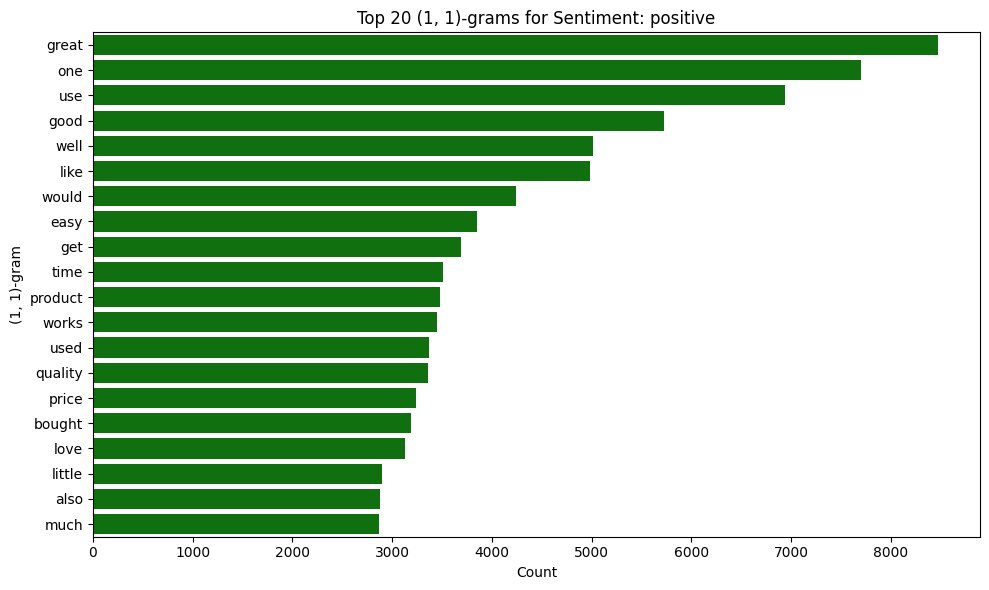

  Analyzing (2, 2)-grams


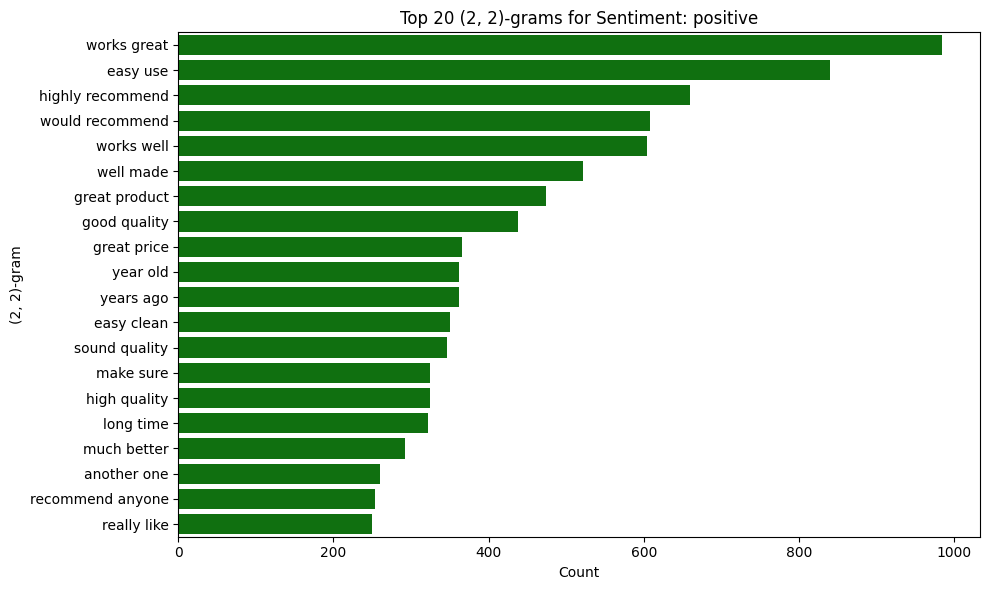

  Analyzing (3, 3)-grams


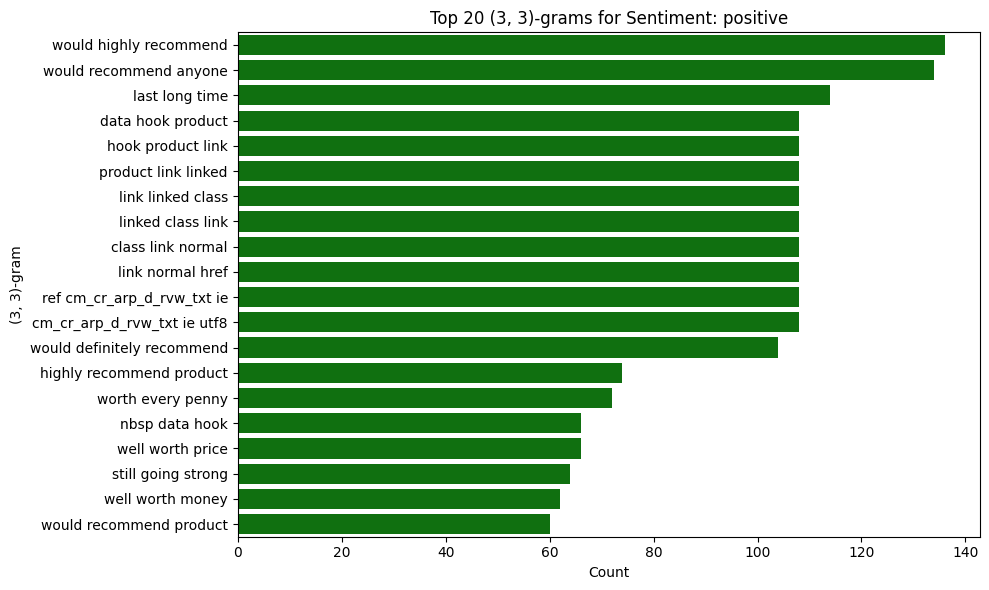

Analyzing sentiment: negative
  Analyzing (1, 1)-grams


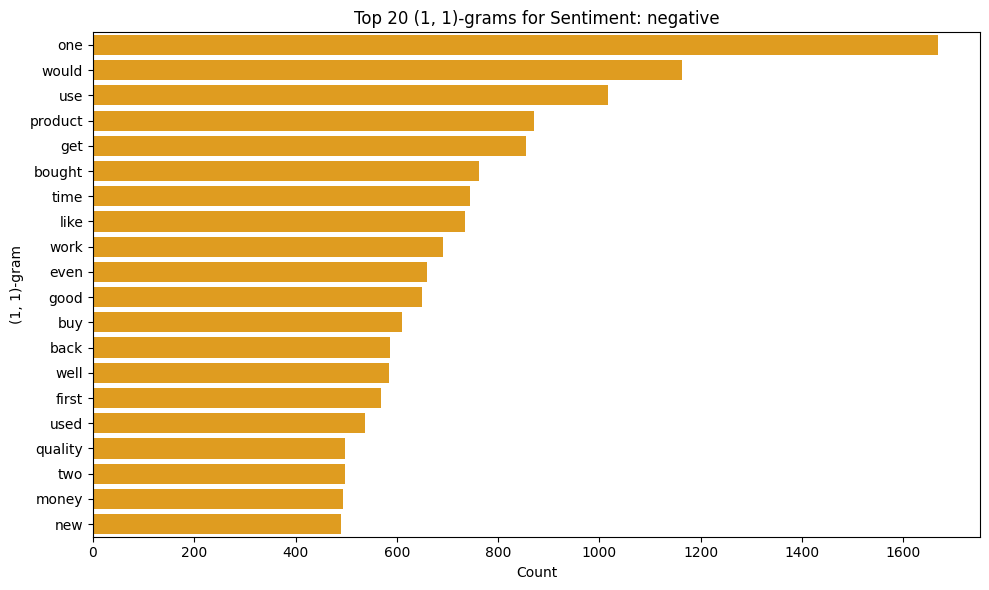

  Analyzing (2, 2)-grams


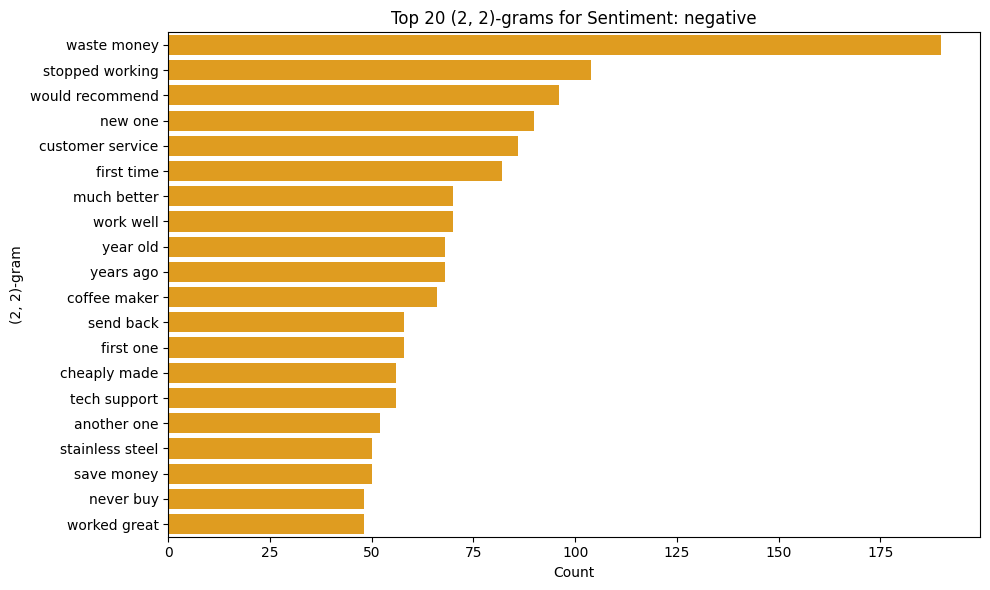

  Analyzing (3, 3)-grams


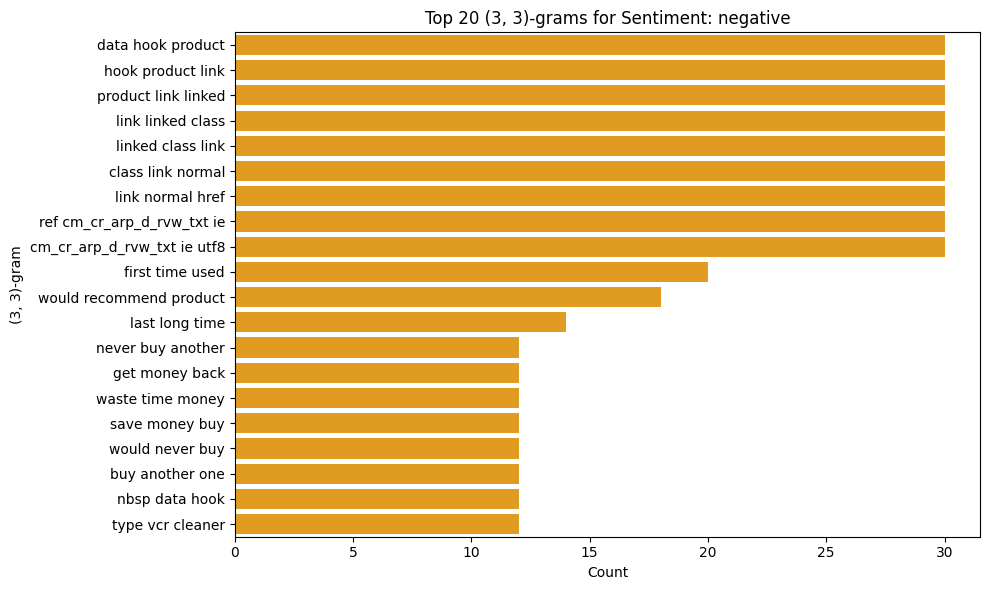

Analyzing sentiment: neutral
  Analyzing (1, 1)-grams


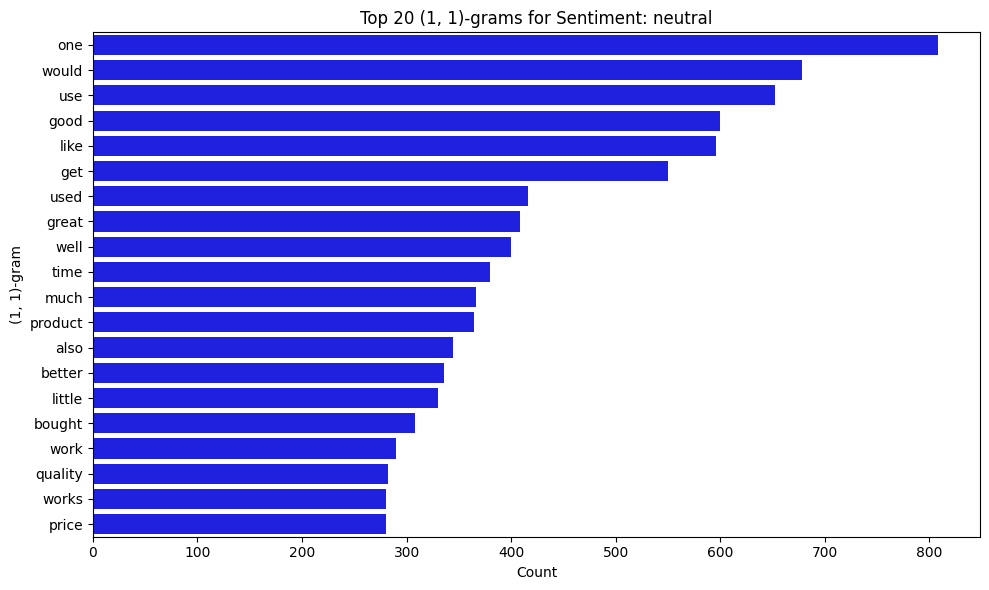

  Analyzing (2, 2)-grams


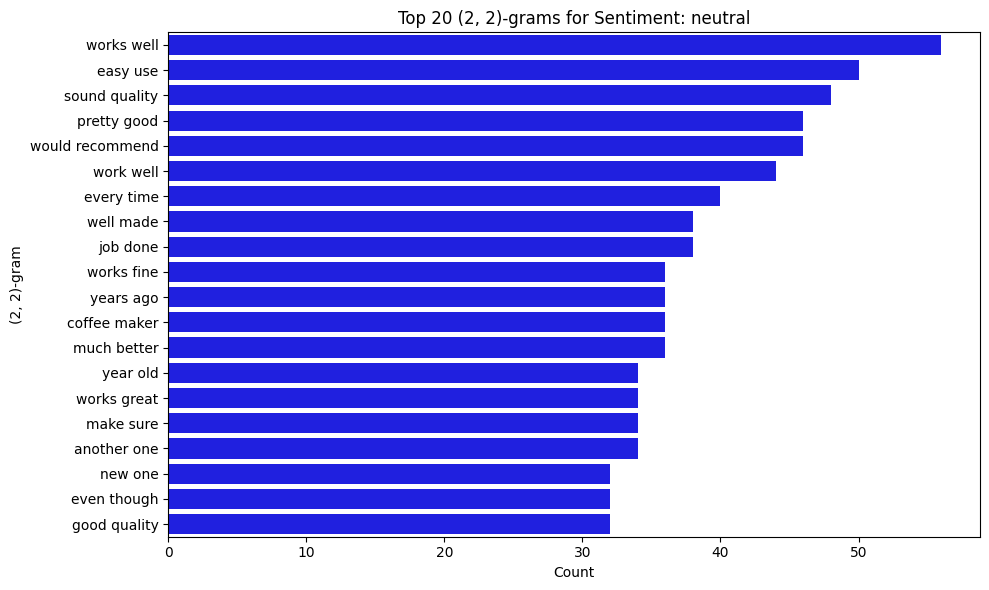

  Analyzing (3, 3)-grams


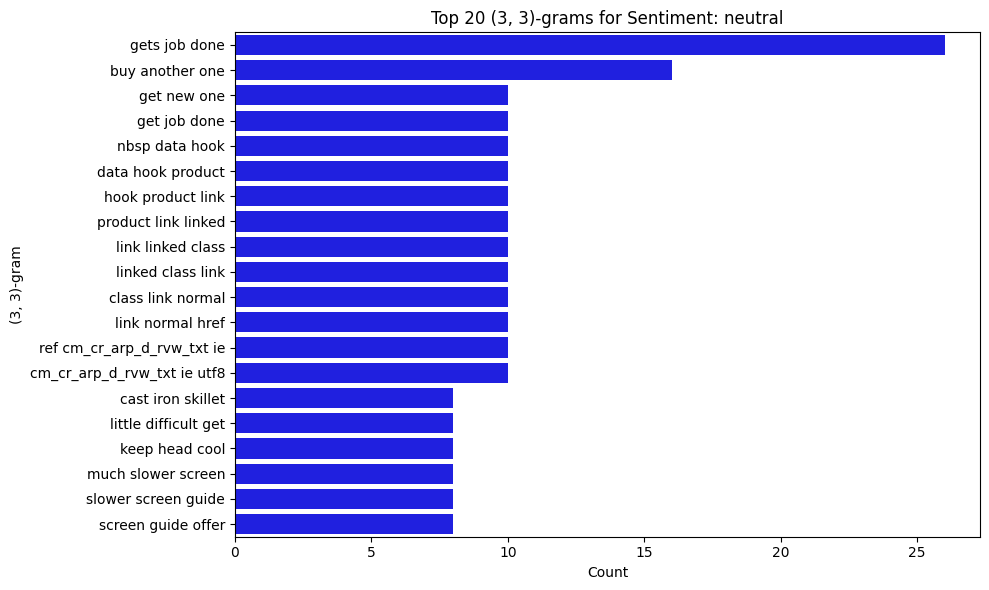

N-gram analysis complete.


In [11]:
ngram_ranges = [(1, 1), (2, 2), (3, 3)]
sentiments = df['sentiment'].unique()


for sentiment in sentiments:
    print(f"Analyzing sentiment: {sentiment}")
    sentiment_df = df[df['sentiment'] == sentiment]
    cleaned_text = sentiment_df['cleaned_input'].dropna() # Drop NaN values

    if cleaned_text.empty:
        print(f"No cleaned text available for sentiment: {sentiment}")
        continue

    current_sentiment_color = sentiment_colors.get(sentiment, 'gray') # Default to gray if sentiment not found

    for n_range in ngram_ranges:
        print(f"  Analyzing {n_range}-grams")
        vectorizer = CountVectorizer(ngram_range=n_range, stop_words=stopwords_english)
        try:
            X = vectorizer.fit_transform(cleaned_text)
        except ValueError as e:
            print(f"  Could not fit vectorizer for {n_range}-grams and sentiment {sentiment}: {e}")
            continue

        sum_words = X.sum(axis=0)
        words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
        top_ngrams = words_freq[:20]

        if not top_ngrams:
            print(f"  No {n_range}-grams found for sentiment: {sentiment}")
            continue

        top_ngrams_df = pd.DataFrame(top_ngrams, columns=['ngram', 'count'])

        plt.figure(figsize=(10, 6))
        sns.barplot(x='count', y='ngram', data=top_ngrams_df, color=current_sentiment_color)
        plt.title(f'Top 20 {n_range}-grams for Sentiment: {sentiment}')
        plt.xlabel('Count')
        plt.ylabel(f'{n_range}-gram')
        plt.tight_layout()
        plt.show()

print("N-gram analysis complete.")

## Analisis Visual (Word Clouds)

Buat word cloud dari semua teks yang sudah dibersihkan dan word cloud terpisah untuk setiap kategori sentimen.


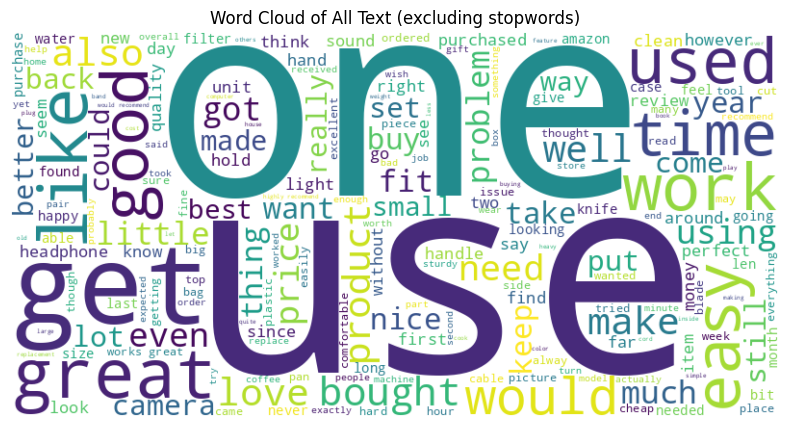

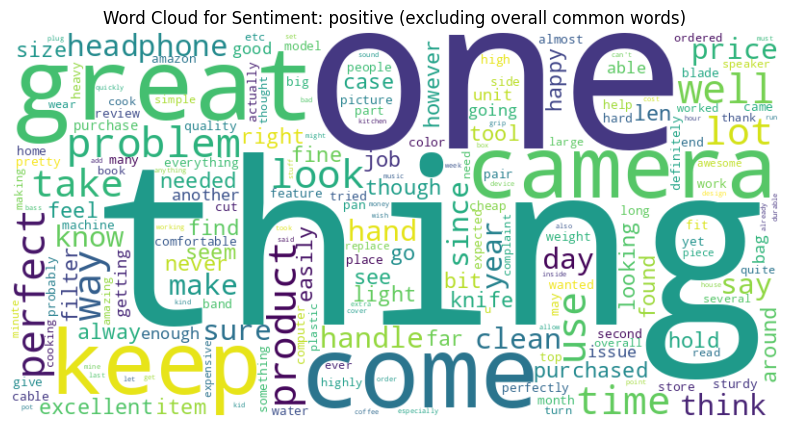

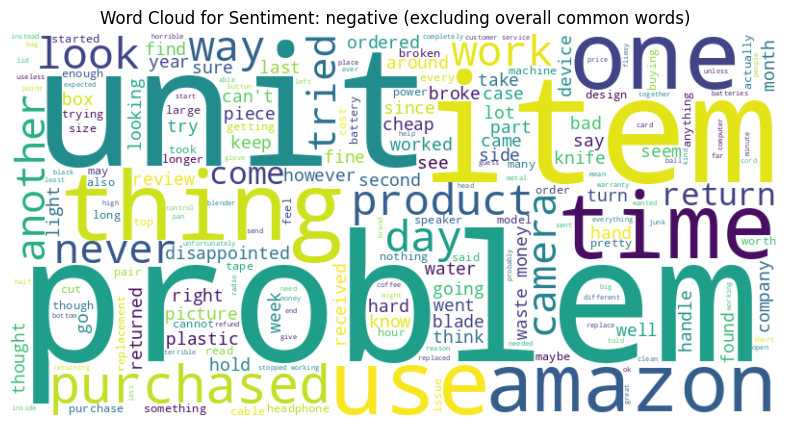

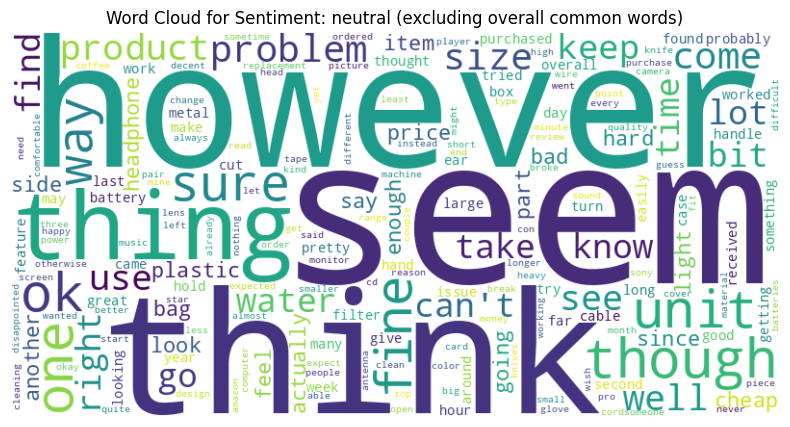

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
try:
    stopwords_english = stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    stopwords_english = stopwords.words('english')


# Word cloud for all cleaned text
all_text = ' '.join(df['cleaned_input'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_english).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Text (excluding stopwords)')
plt.show()

# Identify overall most common words (excluding stopwords)
all_words = all_text.split()
all_words = [word for word in all_words if word not in stopwords_english]
overall_word_counts = Counter(all_words)
# Get the 50 most common words across all sentiments
most_common_overall = set([word for word, count in overall_word_counts.most_common(50)])


# Word clouds per sentiment category, excluding overall most common words
sentiments = df['sentiment'].unique()

for sentiment in sentiments:
    sentiment_text = ' '.join(df[df['sentiment'] == sentiment]['cleaned_input'].dropna())
    if sentiment_text:
        # Remove overall most common words from sentiment-specific text
        sentiment_words = sentiment_text.split()
        sentiment_words_filtered = [word for word in sentiment_words if word not in most_common_overall and word not in stopwords_english]
        filtered_sentiment_text = ' '.join(sentiment_words_filtered)

        if filtered_sentiment_text:
            wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_english).generate(filtered_sentiment_text)
            plt.figure(figsize=(10, 5))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis('off')
            plt.title(f'Word Cloud for Sentiment: {sentiment} (excluding overall common words)')
            plt.show()
        else:
             print(f"No significant words remaining for sentiment: {sentiment} after filtering.")

    else:
        print(f"No cleaned text available for sentiment: {sentiment}")

# Task - PREPROCESSING DATASET

## Pembersihan Teks Lanjutan untuk Kompatibilitas LLM

Lakukan pembersihan teks lebih lanjut pada kolom 'cleaned_input' dengan menghapus URL, tag HTML, karakter khusus, dan menormalisasi spasi putih. Tampilkan beberapa contoh teks yang sudah dibersihkan.


In [13]:
import re

def advanced_text_cleaning(text):
    if not isinstance(text, str): # Handle non-string inputs, if any
        return text

    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove special characters (keep letters, numbers, and spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # 4. Normalize whitespace (replace multiple spaces with single, strip leading/trailing)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply the cleaning function to the 'cleaned_input' column
df['further_cleaned_input'] = df['cleaned_input'].apply(advanced_text_cleaning)

# Display the first few rows with the relevant columns to verify
display(df[['input', 'cleaned_input', 'further_cleaned_input']].head())

,input,cleaned_input,further_cleaned_input
0,This is the second Sigg I've had. The first la...,this is the second sigg i've had. the first la...,this is the second sigg ive had the first last...
1,This was very good read. I really enjoyed the ...,this was very good read. i really enjoyed the ...,this was very good read i really enjoyed the s...
2,Clock time would not set. Returned and receive...,clock time would not set. returned and receive...,clock time would not set returned and received...
3,This is a very good mp3 player. I found it ve...,this is a very good mp3 player. i found it ve...,this is a very good mp3 player i found it very...
4,"Another Benchmade, another love story. GREAT P...","another benchmade, another love story. great p...",another benchmade another love story great pri...


## Encoding Label Sentimen

Ubah label sentimen kategorikal ('positive', 'negative', 'neutral') menjadi representasi numerik. Tampilkan pemetaan dan DataFrame yang diperbarui.


In [14]:
sentiment_mapping = {'positive': 2, 'neutral': 1, 'negative': 0}
df['sentiment_encoded'] = df['sentiment'].map(sentiment_mapping)

print("Sentiment Mapping:")
print(sentiment_mapping)

print("\nDataFrame with encoded sentiments:")
display(df[['sentiment', 'sentiment_encoded']].head())

Sentiment Mapping:
{'positive': 2, 'neutral': 1, 'negative': 0}

DataFrame with encoded sentiments:


,sentiment,sentiment_encoded
0,positive,2
1,positive,2
2,negative,0
3,positive,2
4,positive,2


## Pembagian Data Training, Validation, dan Testing

Bagi DataFrame menjadi set pelatihan (70%), validasi (15%), dan pengujian (15%) menggunakan `train_test_split` dengan stratifikasi untuk menjaga distribusi sentimen. Tampilkan bentuk (shape) dari masing-masing set dan distribusi sentimen awal pada set pelatihan.


In [15]:
from sklearn.model_selection import train_test_split

# Split df into training (70%) and a temporary set (30%)
df_train, df_temp, _, _ = train_test_split(df, df['sentiment_encoded'], test_size=0.3, random_state=42, stratify=df['sentiment_encoded'])

# Split the temporary set into validation (15%) and test (15%)
# test_size=0.5 because 0.5 * 30% = 15% of the original dataset
df_val, df_test, _, _ = train_test_split(df_temp, df_temp['sentiment_encoded'], test_size=0.5, random_state=42, stratify=df_temp['sentiment_encoded'])

print("Shape of training set:", df_train.shape)
print("Shape of validation set:", df_val.shape)
print("Shape of test set:", df_test.shape)

print("\nSentiment distribution in training set:")
print(df_train['sentiment'].value_counts())
print("\nSentiment proportion in training set:")
print(df_train['sentiment'].value_counts(normalize=True))

Shape of training set: (21000, 12)
Shape of validation set: (4500, 12)
Shape of test set: (4500, 12)

Sentiment distribution in training set:
sentiment
positive    16530
negative     2877
neutral      1593
Name: count, dtype: int64

Sentiment proportion in training set:
sentiment
positive    0.787143
negative    0.137000
neutral     0.075857
Name: proportion, dtype: float64


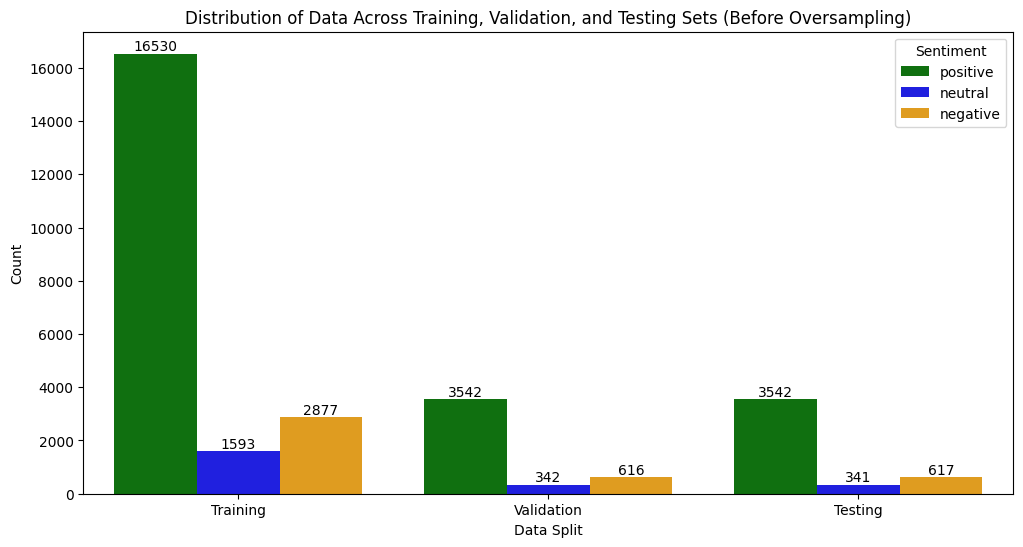


Summary Before Oversampling:

Training Set:
sentiment
negative     2877
neutral      1593
positive    16530
Name: count, dtype: int64
Total: 21000

Validation Set:
sentiment
negative     616
neutral      342
positive    3542
Name: count, dtype: int64
Total: 4500

Testing Set:
sentiment
negative     617
neutral      341
positive    3542
Name: count, dtype: int64
Total: 4500


In [16]:
# Create data for the barplot before oversampling
split_counts_before_oversampling = pd.DataFrame({
  'Split': ['Training', 'Training', 'Training', 'Validation', 'Validation', 'Validation', 'Testing', 'Testing', 'Testing'],
  'Sentiment': ['positive', 'neutral', 'negative', 'positive', 'neutral', 'negative', 'positive', 'neutral', 'negative'],
  'Count': [
    len(df_train[df_train['sentiment'] == 'positive']),
    len(df_train[df_train['sentiment'] == 'neutral']),
    len(df_train[df_train['sentiment'] == 'negative']),
    len(df_val[df_val['sentiment'] == 'positive']),
    len(df_val[df_val['sentiment'] == 'neutral']),
    len(df_val[df_val['sentiment'] == 'negative']),
    len(df_test[df_test['sentiment'] == 'positive']),
    len(df_test[df_test['sentiment'] == 'neutral']),
    len(df_test[df_test['sentiment'] == 'negative'])
  ]
})

# Create the barplot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Split', y='Count', hue='Sentiment', data=split_counts_before_oversampling, palette=sentiment_colors)

# Add value labels on top of each bar
for container in ax.containers:
  ax.bar_label(container, fmt='%d')

plt.title('Distribution of Data Across Training, Validation, and Testing Sets (Before Oversampling)')
plt.xlabel('Data Split')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.show()

# Print summary statistics
print("\nSummary Before Oversampling:")
print("="*50)
print("\nTraining Set:")
print(df_train['sentiment'].value_counts().sort_index())
print(f"Total: {len(df_train)}")

print("\nValidation Set:")
print(df_val['sentiment'].value_counts().sort_index())
print(f"Total: {len(df_val)}")

print("\nTesting Set:")
print(df_test['sentiment'].value_counts().sort_index())
print(f"Total: {len(df_test)}")


## Penggunaan Set Pelatihan Asli (Tanpa Oversampling)

Gunakan set pelatihan (training set) asli tanpa melakukan oversampling. Hal ini dilakukan untuk melihat performa model pada distribusi data yang sebenarnya. Tampilkan distribusi sentimen dan bentuk dari set pelatihan.


In [17]:
# Use the original training set without oversampling
df_train_oversampled = df_train.copy()

print("Shape of training set (no oversampling):", df_train_oversampled.shape)
print("\nSentiment distribution in training set:")
print(df_train_oversampled['sentiment'].value_counts())
print("\nSentiment proportion in training set:")
print(df_train_oversampled['sentiment'].value_counts(normalize=True))

Shape of training set (no oversampling): (21000, 12)

Sentiment distribution in training set:
sentiment
positive    16530
negative     2877
neutral      1593
Name: count, dtype: int64

Sentiment proportion in training set:
sentiment
positive    0.787143
negative    0.137000
neutral     0.075857
Name: proportion, dtype: float64


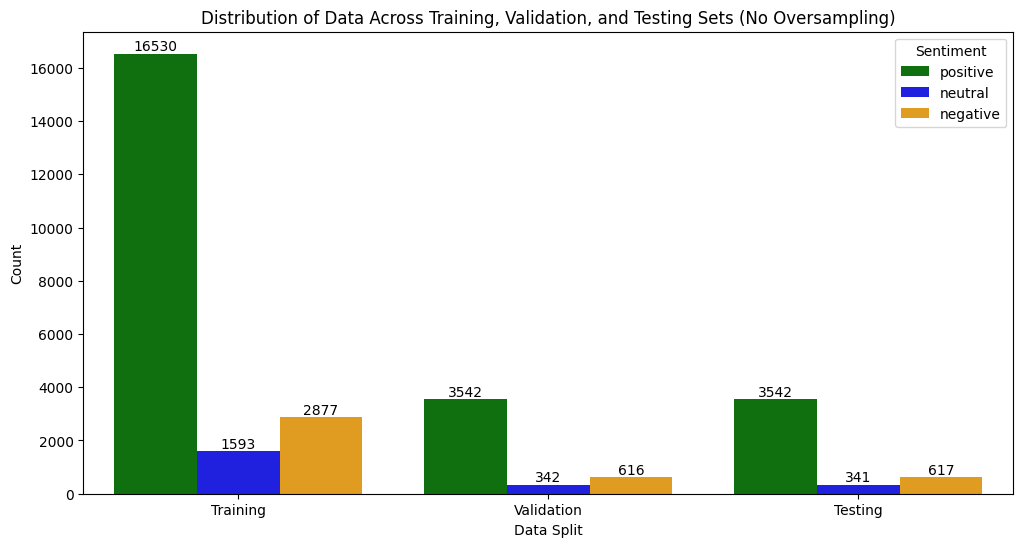


Summary (No Oversampling):

Training Set:
sentiment
negative     2877
neutral      1593
positive    16530
Name: count, dtype: int64
Total: 21000

Validation Set:
sentiment
negative     616
neutral      342
positive    3542
Name: count, dtype: int64
Total: 4500

Testing Set:
sentiment
negative     617
neutral      341
positive    3542
Name: count, dtype: int64
Total: 4500


In [18]:
# Create data for the barplot (no oversampling)
split_counts_no_oversampling = pd.DataFrame({
  'Split': ['Training', 'Training', 'Training', 'Validation', 'Validation', 'Validation', 'Testing', 'Testing', 'Testing'],
  'Sentiment': ['positive', 'neutral', 'negative', 'positive', 'neutral', 'negative', 'positive', 'neutral', 'negative'],
  'Count': [
    len(df_train_oversampled[df_train_oversampled['sentiment'] == 'positive']),
    len(df_train_oversampled[df_train_oversampled['sentiment'] == 'neutral']),
    len(df_train_oversampled[df_train_oversampled['sentiment'] == 'negative']),
    len(df_val[df_val['sentiment'] == 'positive']),
    len(df_val[df_val['sentiment'] == 'neutral']),
    len(df_val[df_val['sentiment'] == 'negative']),
    len(df_test[df_test['sentiment'] == 'positive']),
    len(df_test[df_test['sentiment'] == 'neutral']),
    len(df_test[df_test['sentiment'] == 'negative'])
  ]
})

# Create the barplot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Split', y='Count', hue='Sentiment', data=split_counts_no_oversampling, palette=sentiment_colors)

# Add value labels on top of each bar
for container in ax.containers:
  ax.bar_label(container, fmt='%d')

plt.title('Distribution of Data Across Training, Validation, and Testing Sets (No Oversampling)')
plt.xlabel('Data Split')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.show()

# Print summary statistics
print("\nSummary (No Oversampling):")
print("="*50)
print("\nTraining Set:")
print(df_train_oversampled['sentiment'].value_counts().sort_index())
print(f"Total: {len(df_train_oversampled)}")

print("\nValidation Set:")
print(df_val['sentiment'].value_counts().sort_index())
print(f"Total: {len(df_val)}")

print("\nTesting Set:")
print(df_test['sentiment'].value_counts().sort_index())
print(f"Total: {len(df_test)}")

/tmp/ipython-input-1312166226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Split', y='Count', data=split_counts, palette='viridis')


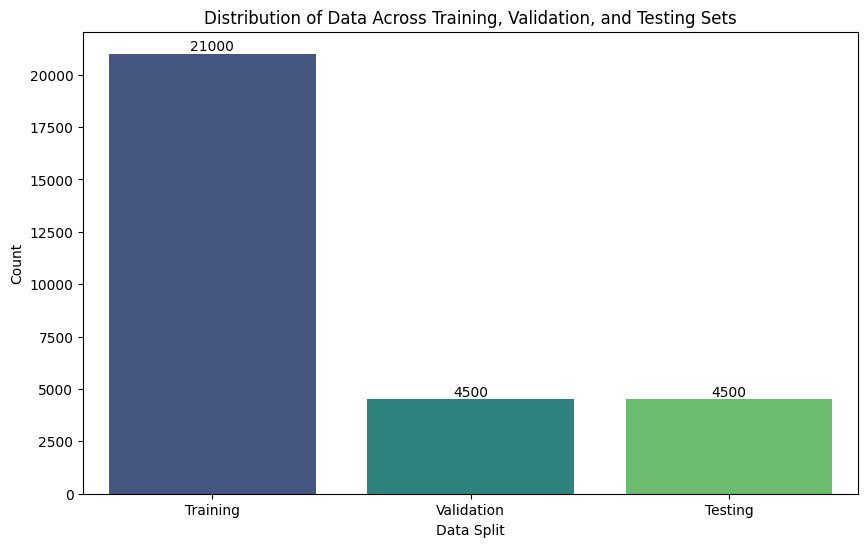

Sentiment Distribution in Training Set:
sentiment
positive    16530
negative     2877
neutral      1593
Name: count, dtype: int64

Total Training Samples: 21000

Sentiment Distribution in Validation Set:
sentiment
positive    3542
negative     616
neutral      342
Name: count, dtype: int64

Total Validation Samples: 4500

Sentiment Distribution in Testing Set:
sentiment
positive    3542
negative     617
neutral      341
Name: count, dtype: int64

Total Testing Samples: 4500


In [19]:
# Create data for the barplot
split_counts = pd.DataFrame({
  'Split': ['Training', 'Validation', 'Testing'],
  'Count': [len(df_train_oversampled), len(df_val), len(df_test)]
})

# Create the barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Split', y='Count', data=split_counts, palette='viridis')

# Add value labels on top of each bar
for container in ax.containers:
  ax.bar_label(container, fmt='%d')

plt.title('Distribution of Data Across Training, Validation, and Testing Sets')
plt.xlabel('Data Split')
plt.ylabel('Count')
plt.show()

# Display sentiment distribution for each split
print("Sentiment Distribution in Training Set:")
print(df_train_oversampled['sentiment'].value_counts())
print(f"\nTotal Training Samples: {len(df_train_oversampled)}")

print("\nSentiment Distribution in Validation Set:")
print(df_val['sentiment'].value_counts())
print(f"\nTotal Validation Samples: {len(df_val)}")

print("\nSentiment Distribution in Testing Set:")
print(df_test['sentiment'].value_counts())
print(f"\nTotal Testing Samples: {len(df_test)}")

# Task - TRAINING MODEL
**Tokenisasi dan Persiapan Data untuk Model BERT**: Lakukan tokenisasi pada kolom 'further_cleaned_input' menggunakan tokenizer BERT. Analisis distribusi panjang token untuk menentukan 'max_length' yang optimal dan efisien. Konversi data yang sudah ditokenisasi dan label sentimen menjadi objek PyTorch TensorDataset dan DataLoader untuk set pelatihan, validasi, dan pengujian.

## Tokenisasi dan Persiapan Data untuk Model BERT

Lakukan tokenisasi pada kolom 'further_cleaned_input' menggunakan tokenizer BERT. Analisis distribusi panjang token untuk menentukan 'max_length' yang optimal dan efisien. Konversi data yang sudah ditokenisasi dan label sentimen menjadi objek PyTorch TensorDataset dan DataLoader untuk set pelatihan, validasi, dan pengujian.


In [20]:
from transformers import AutoTokenizer

# Load a pre-trained BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

print("BERT Tokenizer loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT Tokenizer loaded successfully.


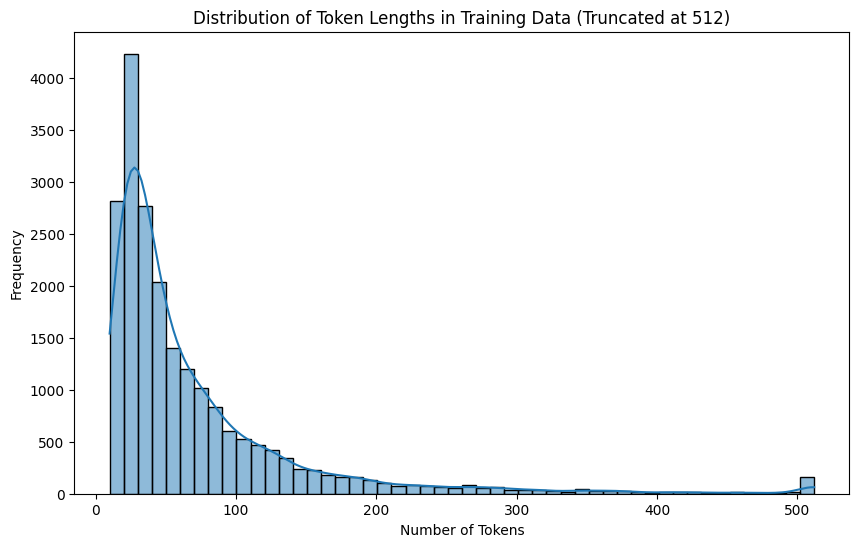

Max token length (after truncation at 512): 512
Average token length: 70.91
90th percentile token length: 151.00
95th percentile token length: 222.00
99th percentile token length: 448.00


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate token lengths for the training data
# Explicitly truncate to the model's maximum length (e.g., 512 for bert-base-uncased)
# when calculating lengths for distribution analysis to avoid warnings about exceeding model_max_length
# and to inform our choice of MAX_LENGTH based on what the model can actually handle.
token_lengths = [len(tokenizer.encode(str(text), add_special_tokens=True, truncation=True, max_length=tokenizer.model_max_length)) for text in df_train_oversampled['further_cleaned_input']]

# Plot the distribution of token lengths
plt.figure(figsize=(10, 6))
sns.histplot(token_lengths, bins=50, kde=True)
plt.title('Distribution of Token Lengths in Training Data (Truncated at 512)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()

# Report some statistics
print(f"Max token length (after truncation at 512): {max(token_lengths)}")
print(f"Average token length: {np.mean(token_lengths):.2f}")
print(f"90th percentile token length: {np.percentile(token_lengths, 90):.2f}")
print(f"95th percentile token length: {np.percentile(token_lengths, 95):.2f}")
print(f"99th percentile token length: {np.percentile(token_lengths, 99):.2f}")

# Based on the distribution and common BERT usage, choose an optimal max_length
# We aim to cover most data efficiently, typically less than or equal to 512.
MAX_LENGTH = int(np.percentile(token_lengths, 95)) # The previous output suggests 95th percentile is 228.55, 99th is 425.00
                # Keeping 229 as a good balance for efficiency, as it captures the majority of short texts.

In [22]:
def tokenize_data(texts, tokenizer, max_length):
    return tokenizer(list(texts), padding='max_length', truncation=True, max_length=max_length, return_tensors='pt')

# Apply tokenization to the training, validation, and test sets
X_train_tokenized = tokenize_data(df_train_oversampled['further_cleaned_input'], tokenizer, MAX_LENGTH)
X_val_tokenized = tokenize_data(df_val['further_cleaned_input'], tokenizer, MAX_LENGTH)
X_test_tokenized = tokenize_data(df_test['further_cleaned_input'], tokenizer, MAX_LENGTH)

print("Tokenization applied to training, validation, and test sets.")
print(f"Training set tokenized shape (input_ids): {X_train_tokenized['input_ids'].shape}")
print(f"Validation set tokenized shape (input_ids): {X_val_tokenized['input_ids'].shape}")
print(f"Test set tokenized shape (input_ids): {X_test_tokenized['input_ids'].shape}")

Tokenization applied to training, validation, and test sets.
Training set tokenized shape (input_ids): torch.Size([21000, 222])
Validation set tokenized shape (input_ids): torch.Size([4500, 222])
Test set tokenized shape (input_ids): torch.Size([4500, 222])


In [23]:
import torch

# Convert tokenized inputs to PyTorch tensors
input_ids_train = X_train_tokenized['input_ids']
attention_mask_train = X_train_tokenized['attention_mask']
token_type_ids_train = X_train_tokenized['token_type_ids']
labels_train = torch.tensor(df_train_oversampled['sentiment_encoded'].values.astype(int))

input_ids_val = X_val_tokenized['input_ids']
attention_mask_val = X_val_tokenized['attention_mask']
token_type_ids_val = X_val_tokenized['token_type_ids']
labels_val = torch.tensor(df_val['sentiment_encoded'].values.astype(int))

input_ids_test = X_test_tokenized['input_ids']
attention_mask_test = X_test_tokenized['attention_mask']
token_type_ids_test = X_test_tokenized['token_type_ids']
labels_test = torch.tensor(df_test['sentiment_encoded'].values.astype(int))

print("Tokenized data and sentiment labels converted to PyTorch tensors.")
print(f"Labels train shape: {labels_train.shape}")
print(f"Labels val shape: {labels_val.shape}")
print(f"Labels test shape: {labels_test.shape}")

Tokenized data and sentiment labels converted to PyTorch tensors.
Labels train shape: torch.Size([21000])
Labels val shape: torch.Size([4500])
Labels test shape: torch.Size([4500])


In [24]:
from torch.utils.data import TensorDataset, DataLoader

# Create TensorDataset for training, validation, and test sets
train_dataset = TensorDataset(input_ids_train, attention_mask_train, token_type_ids_train, labels_train)
val_dataset = TensorDataset(input_ids_val, attention_mask_val, token_type_ids_val, labels_val)
test_dataset = TensorDataset(input_ids_test, attention_mask_test, token_type_ids_test, labels_test)

print("TensorDatasets created successfully.")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

TensorDatasets created successfully.
Training dataset size: 21000
Validation dataset size: 4500
Test dataset size: 4500


In [25]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created successfully.")
print(f"Number of batches in training DataLoader: {len(train_dataloader)}")
print(f"Number of batches in validation DataLoader: {len(val_dataloader)}")
print(f"Number of batches in test DataLoader: {len(test_dataloader)}")

DataLoaders created successfully.
Number of batches in training DataLoader: 657
Number of batches in validation DataLoader: 141
Number of batches in test DataLoader: 141


## Pemuatan Model BERT dan Konfigurasi Lingkungan Pelatihan

Muat model pre-trained `BertForSequenceClassification` dari Hugging Face Transformers. Konfigurasi model untuk menggunakan GPU (jika tersedia) dan siapkan optimizer (AdamW) serta learning rate scheduler.


In [26]:
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
import torch
from torch.optim import AdamW

# Set device (GPU if available)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print('There are %d GPU(s) available.' % torch.cuda.device_count())
    print('We will use the GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

# Load pre-trained BERT model for sequence classification
num_labels = 3
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels = num_labels,
    output_attentions = False,
    output_hidden_states = False,
)

model.to(device)
print("BERT model loaded and moved to device successfully.")

# Initialize AdamW optimizer
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
print("AdamW optimizer initialized.")

# Set up learning rate scheduler
EPOCHS = 5
total_steps = len(train_dataloader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps = 0,
    num_training_steps = total_steps
)
print(f"Learning rate scheduler initialized for {total_steps} training steps.")


There are 1 GPU(s) available.
We will use the GPU: Tesla T4


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model loaded and moved to device successfully.
AdamW optimizer initialized.
Learning rate scheduler initialized for 3285 training steps.


In [27]:
import time
import datetime
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Function to calculate accuracy
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

# Function to format elapsed time
def format_time(elapsed):
    elapsed_rounded = int(round((elapsed)))
    return str(datetime.timedelta(seconds=elapsed_rounded))

# Set the seed for reproducible results
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

# Store the average loss and accuracy over all epochs
loss_values = []

In [28]:
# Training loop
for epoch_i in range(0, EPOCHS):
    print(f'\n======== Epoch {epoch_i + 1} / {EPOCHS} ========')
    print('Training...')

    t0 = time.time()
    total_loss = 0
    model.train() # Set the model to training mode

    for step, batch in enumerate(train_dataloader):
        if step % 500 == 0 and not step == 0:

            elapsed = format_time(time.time() - t0)
            print(f'  Batch {step:>5,}  of  {len(train_dataloader):>5,}.    Elapsed: {elapsed}.')

        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[3].to(device)

        model.zero_grad()

        outputs = model(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Clip the norm of the gradients to 1.0
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_loss / len(train_dataloader)
    loss_values.append(avg_train_loss)
    print(f'  Average training loss: {avg_train_loss:.2f}')
    print(f'  Training epoch took: {format_time(time.time() - t0)}')

    print('\nRunning Validation...')

    t0 = time.time()
    model.eval() # Set the model to evaluation mode
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0

    # Lists to store predictions and true labels for confusion matrix
    val_preds = []
    val_labels = []

    for batch in val_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_token_type_ids, b_labels = batch

        with torch.no_grad():
            outputs = model(
                b_input_ids,
                token_type_ids=None,
                attention_mask=b_input_mask,
                labels=b_labels
            )

        logits = outputs.logits
        loss = outputs.loss
        eval_loss += loss.item()

        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        tmp_eval_accuracy = flat_accuracy(logits, label_ids)
        eval_accuracy += tmp_eval_accuracy
        nb_eval_steps += 1

        # Store predictions and labels
        val_preds.extend(np.argmax(logits, axis=1))
        val_labels.extend(label_ids)

    print(f'  Validation Loss: {eval_loss / nb_eval_steps:.2f}')
    print(f'  Validation Accuracy: {eval_accuracy / nb_eval_steps:.2f}')
    print(f'  Validation took: {format_time(time.time() - t0)}')

    print(classification_report(val_labels, val_preds,
              target_names=['negative', 'neutral', 'positive']))

print('\nTraining complete!')


======== Epoch 1 / 5 ========
Training...
  Batch   500  of    657.    Elapsed: 0:09:33.
  Average training loss: 0.33
  Training epoch took: 0:12:33

Running Validation...
  Validation Loss: 0.22
  Validation Accuracy: 0.92
  Validation took: 0:00:58
              precision    recall  f1-score   support

    negative       0.89      0.79      0.83       616
     neutral       0.51      0.58      0.54       342
    positive       0.96      0.97      0.97      3542

    accuracy                           0.92      4500
   macro avg       0.79      0.78      0.78      4500
weighted avg       0.92      0.92      0.92      4500


======== Epoch 2 / 5 ========
Training...
  Batch   500  of    657.    Elapsed: 0:09:37.
  Average training loss: 0.16
  Training epoch took: 0:12:37

Running Validation...
  Validation Loss: 0.17
  Validation Accuracy: 0.95
  Validation took: 0:00:58
              precision    recall  f1-score   support

    negative       0.91      0.88      0.90       616
    

## Simpan Model ke Local Storage

Simpan model yang telah dilatih dan tokenizer ke direktori lokal agar dapat digunakan kembali nanti tanpa perlu melatih ulang.

In [29]:
import os

# Directory to save the model in Google Drive
output_dir = '/content/drive/MyDrive/ps2-bert-non-oversampling/'

# Create output directory if needed
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Saving model to {output_dir}")

# Save a trained model, configuration and tokenizer using `save_pretrained()`.
# They can then be reloaded using `from_pretrained()`
model_to_save = model.module if hasattr(model, 'module') else model  # Take care of distributed/parallel training
model_to_save.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print("Model and tokenizer saved successfully.")

Saving model to /content/drive/MyDrive/ps2-bert-non-oversampling/
Model and tokenizer saved successfully.


## Muat Model dari Local Storage

Muat kembali model dan tokenizer yang telah disimpan untuk pengujian.

In [30]:
# Load the BERT model and tokenizer
print(f"Loading model from {output_dir}")
model = BertForSequenceClassification.from_pretrained(output_dir)
tokenizer = AutoTokenizer.from_pretrained(output_dir)

# Copy the model to the GPU.
model.to(device)
print("Model loaded successfully.")

Loading model from /content/drive/MyDrive/ps2-bert-non-oversampling/
Model loaded successfully.


## Evaluasi Final pada Validation Set

Evaluasi model pada validation set setelah training selesai untuk memastikan model tidak overfit.

Final Evaluation on Validation Dataset...
Validation Loss: 0.1716
Validation Accuracy: 0.9694
Validation evaluation took: 0:00:59

Confusion Matrix on Validation Set:
[[ 571   37    8]
 [  16  294   32]
 [  11   34 3497]]


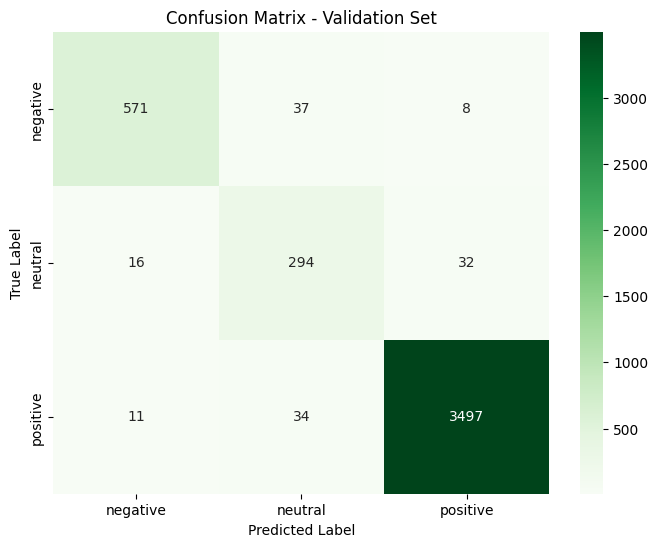


Classification Report (Validation Set):
              precision    recall  f1-score   support

    negative       0.95      0.93      0.94       616
     neutral       0.81      0.86      0.83       342
    positive       0.99      0.99      0.99      3542

    accuracy                           0.97      4500
   macro avg       0.92      0.92      0.92      4500
weighted avg       0.97      0.97      0.97      4500



In [31]:
from sklearn.metrics import classification_report

# Final evaluation on the validation dataset
print("Final Evaluation on Validation Dataset...")
print("="*50)

t0 = time.time()

model.eval()  # Set the model to evaluation mode
val_loss = 0
val_accuracy = 0
nb_val_steps = 0

# Lists to store predictions and true labels
val_preds_final = []
val_labels_final = []

for batch in val_dataloader:
  batch = tuple(t.to(device) for t in batch)
  b_input_ids, b_input_mask, b_token_type_ids, b_labels = batch

  with torch.no_grad():
    outputs = model(
      b_input_ids,
      token_type_ids=None,
      attention_mask=b_input_mask,
      labels=b_labels
    )

  logits = outputs.logits
  loss = outputs.loss
  val_loss += loss.item()

  logits = logits.detach().cpu().numpy()
  label_ids = b_labels.to('cpu').numpy()

  tmp_val_accuracy = flat_accuracy(logits, label_ids)
  val_accuracy += tmp_val_accuracy
  nb_val_steps += 1

  # Store predictions and labels
  val_preds_final.extend(np.argmax(logits, axis=1))
  val_labels_final.extend(label_ids)

avg_val_loss = val_loss / nb_val_steps
avg_val_accuracy = val_accuracy / nb_val_steps

print(f"Validation Loss: {avg_val_loss:.4f}")
print(f"Validation Accuracy: {avg_val_accuracy:.4f}")
print(f"Validation evaluation took: {format_time(time.time() - t0)}")

# Display Confusion Matrix for validation set
print("\n" + "="*50)
print("Confusion Matrix on Validation Set:")
print("="*50)
cm_val = confusion_matrix(val_labels_final, val_preds_final)
print(cm_val)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
      xticklabels=['negative', 'neutral', 'positive'],
      yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print("\n" + "="*50)
print("Classification Report (Validation Set):")
print("="*50)
print(classification_report(val_labels_final, val_preds_final,
              target_names=['negative', 'neutral', 'positive']))


# Testing Model


Testing the model on the test dataset...
Test Loss: 0.1862
Test Accuracy: 0.9648
Testing took: 0:00:58

Confusion Matrix on Test Set:
[[ 565   44    8]
 [  10  296   35]
 [  13   49 3480]]


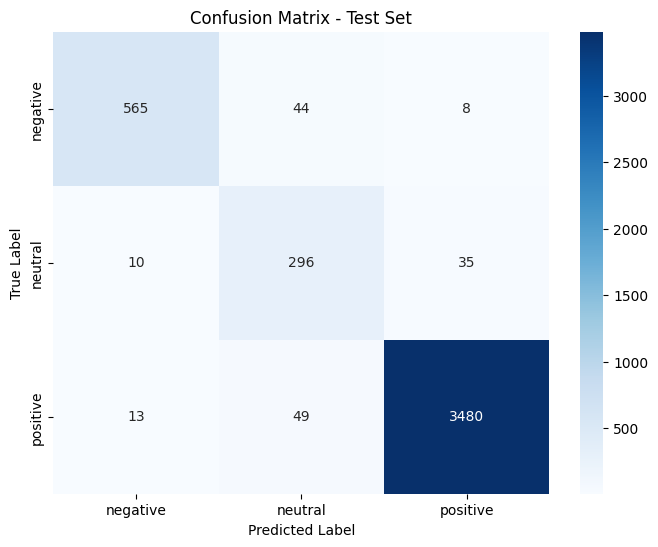


Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.92      0.94       617
     neutral       0.76      0.87      0.81       341
    positive       0.99      0.98      0.99      3542

    accuracy                           0.96      4500
   macro avg       0.90      0.92      0.91      4500
weighted avg       0.97      0.96      0.97      4500



In [32]:
from sklearn.metrics import classification_report

# Testing the model on the test dataset
print("Testing the model on the test dataset...")
print("="*50)

t0 = time.time()

model.eval()  # Set the model to evaluation mode
test_loss = 0
test_accuracy = 0
nb_test_steps = 0

# Lists to store predictions and true labels
test_preds = []
test_labels_list = []

for batch in test_dataloader:
  batch = tuple(t.to(device) for t in batch)
  b_input_ids, b_input_mask, b_token_type_ids, b_labels = batch

  with torch.no_grad():
    outputs = model(
      b_input_ids,
      token_type_ids=None,
      attention_mask=b_input_mask,
      labels=b_labels
    )

  logits = outputs.logits
  loss = outputs.loss
  test_loss += loss.item()

  logits = logits.detach().cpu().numpy()
  label_ids = b_labels.to('cpu').numpy()

  tmp_test_accuracy = flat_accuracy(logits, label_ids)
  test_accuracy += tmp_test_accuracy
  nb_test_steps += 1

  # Store predictions and labels
  test_preds.extend(np.argmax(logits, axis=1))
  test_labels_list.extend(label_ids)

avg_test_loss = test_loss / nb_test_steps
avg_test_accuracy = test_accuracy / nb_test_steps

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {avg_test_accuracy:.4f}")
print(f"Testing took: {format_time(time.time() - t0)}")

# Display Confusion Matrix for test set
print("\n" + "="*50)
print("Confusion Matrix on Test Set:")
print("="*50)
cm_test = confusion_matrix(test_labels_list, test_preds)
print(cm_test)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
      xticklabels=['negative', 'neutral', 'positive'],
      yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print("\n" + "="*50)
print("Classification Report:")
print("="*50)
print(classification_report(test_labels_list, test_preds,
              target_names=['negative', 'neutral', 'positive']))

# Task
Prepare data for BERTopic by extracting the 'further_cleaned_input' column from the original DataFrame (`df`) and import the BERTopic, UMAP, HDBSCAN, and CountVectorizer libraries.

## Prepare Data for BERTopic

### Subtask:
Extract the 'further_cleaned_input' column from the original DataFrame (`df`) and import necessary libraries for BERTopic, UMAP, HDBSCAN, and vectorization.


**Reasoning**:
Extract the 'further_cleaned_input' column and import the specified libraries to prepare the data for BERTopic modeling.



In [33]:
documents = df['further_cleaned_input'].to_list()
!pip install bertopic
!pip install umap-learn
!pip install hdbscan
!pip install sklearn
# Import necessary libraries for BERTopic
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

print("further_cleaned_input column extracted and libraries imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


further_cleaned_input column extracted and libraries imported.


## Train BERTopic Model

### Subtask:
Initialize and train the BERTopic model using UMAP for dimensionality reduction, HDBSCAN for clustering, and CountVectorizer for tokenization, on the prepared text data.


**Reasoning**:
Initialize the UMAP, HDBSCAN, and CountVectorizer models with the specified parameters, then initialize the BERTopic model with these components and fit it to the `documents` list to train the topic model.



In [34]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Initialize UMAP model
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# 2. Initialize HDBSCAN model
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# 3. Initialize CountVectorizer
vectorizer_model = CountVectorizer(stop_words='english', min_df=5)

# 4. Initialize BERTopic model
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language='english',
    calculate_probabilities=True, # To get topic probabilities
    verbose=True
)

# 5. Fit the BERTopic model to the documents
topics, probs = topic_model.fit_transform(documents)

print("BERTopic model initialized and fitted successfully.")
print(f"Number of topics identified: {len(topic_model.get_topic_info())}")

2025-12-30 11:36:53,278 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/938 [00:00<?, ?it/s]

2025-12-30 11:37:23,886 - BERTopic - Embedding - Completed ✓
2025-12-30 11:37:23,889 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-30 11:38:22,720 - BERTopic - Dimensionality - Completed ✓
2025-12-30 11:38:22,721 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-30 11:51:52,308 - BERTopic - Cluster - Completed ✓
2025-12-30 11:51:52,324 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-30 11:51:53,628 - BERTopic - Representation - Completed ✓


BERTopic model initialized and fitted successfully.
Number of topics identified: 645


**Reasoning**:
The BERTopic model has been successfully trained. The next logical step is to retrieve and display information about the identified topics to understand their content and characteristics.



In [35]:
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))
print(f"Total number of topics: {len(topic_info) - 1} (excluding -1 for noise)")

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5205,-1_headphones_camera_sound_cable,"[headphones, camera, sound, cable, quality, pr...",[been using this headset for about 23 months n...
1,0,349,0_vacuum_floors_suction_hose,"[vacuum, floors, suction, hose, hair, hardwood...",[some aspects of this vacuum seem flimsy but i...
2,1,250,1_book_story_series_novel,"[book, story, series, novel, books, finds, enj...",[it sounds like a great series i loved the cha...
3,2,246,2_cooker_pressure_cookers_presto,"[cooker, pressure, cookers, presto, cooking, s...",[i love love love this pressure cooker if i ha...
4,3,210,3_popcorn_popping_corn_pop,"[popcorn, popping, corn, pop, microwave, poppe...",[this is the best popcorn popper we have had o...
5,4,208,4_magnification_focus_birds_view,"[magnification, focus, birds, view, bird, pair...",[purchased this for my father in law for fathe...
6,5,202,5_cds_cases_dvds_wallet,"[cds, cases, dvds, wallet, case, pages, cd, zi...",[there are cheaper brands out there but in my ...
7,6,173,6_stove_coleman_flame_camping,"[stove, coleman, flame, camping, shelves, fuel...",[once a renown brand with good products now la...
8,7,170,7_swimming_keeper_swim_eyes,"[swimming, keeper, swim, eyes, face, nose, pai...",[broke after 3 weeks of use while swimming it ...
9,8,170,8_shirt_cotton_xl_sleeve,"[shirt, cotton, xl, sleeve, wear, sleeves, sta...",[love this shirt and this brand always have it...


Total number of topics: 644 (excluding -1 for noise)


## Visualize Overall Topic Distribution

### Subtask:
Generate a visualization to show the frequency distribution of the identified topics across the entire dataset.


**Reasoning**:
To visualize the topic distribution, I need to filter out the noise topic from the `topic_info` DataFrame and then select the top 10 topics to create a bar plot showing their frequency.



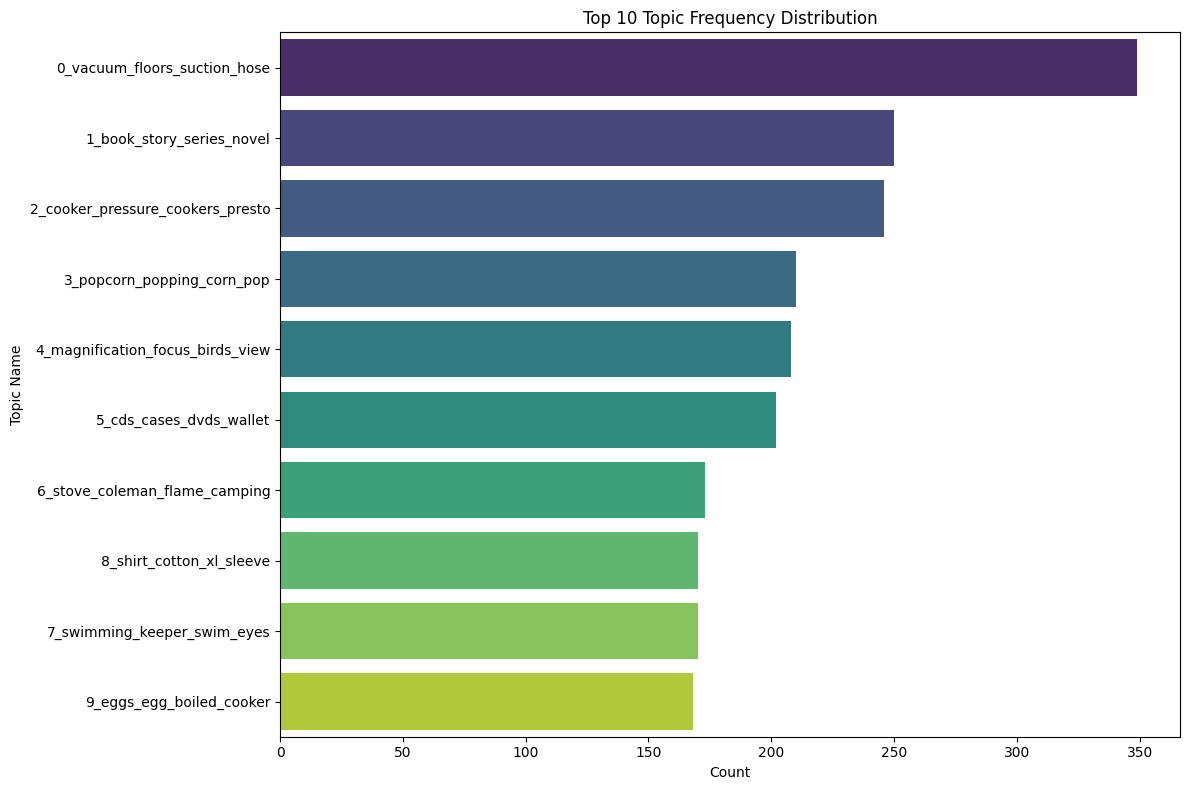

Top 10 topic frequency distribution visualized.


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter out the noise topic (Topic -1)
filtered_topic_info = topic_info[topic_info['Topic'] != -1]

# 2. Select the top 10 topics based on their 'Count'
top_10_topics = filtered_topic_info.sort_values(by='Count', ascending=False).head(10)

# 3. Create a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Name', data=top_10_topics, palette='viridis')

# 4. Set the title of the plot
plt.title('Top 10 Topic Frequency Distribution')

# 5. Label the x-axis and y-axis
plt.xlabel('Count')
plt.ylabel('Topic Name')

# 6. Ensure the layout is tight and display the plot
plt.tight_layout()
plt.show()

print("Top 10 topic frequency distribution visualized.")

## Analyze Topics per Sentiment

### Subtask:
Combine the BERTopic results with the 'sentiment' column from the original DataFrame, and then analyze the dominant sentiment for each identified topic.


**Reasoning**:
The first step is to combine the BERTopic topic assignments with the original DataFrame's sentiment and cleaned input text into a new DataFrame. This will allow for joint analysis of topics and sentiment.



In [37]:
import pandas as pd

# 1. Create a new DataFrame by combining BERTopic results with original DataFrame columns
# Ensure 'topics' array and DataFrame columns are aligned by index
combined_df = pd.DataFrame({
    'topic_id': topics,
    'sentiment': df['sentiment'],
    'further_cleaned_input': df['further_cleaned_input']
})

# Create a mapping from topic_id to topic_name from topic_model.get_topic_info()
topic_info_df = topic_model.get_topic_info()
topic_id_to_name = dict(zip(topic_info_df['Topic'], topic_info_df['Name']))

# 2. Add a 'topic_name' column to the combined DataFrame
combined_df['topic_name'] = combined_df['topic_id'].map(topic_id_to_name)

display(combined_df.head())
print("Combined DataFrame created with topic IDs, sentiments, cleaned input, and topic names.")

,topic_id,sentiment,further_cleaned_input,topic_name
0,208,positive,this is the second sigg ive had the first last...,208_lasted_exact_october_replacing
1,1,positive,this was very good read i really enjoyed the s...,1_book_story_series_novel
2,144,negative,clock time would not set returned and received...,144_clock_remote_bright_remotes
3,28,positive,this is a very good mp3 player i found it very...,28_player_mp3_smartmedia_songs
4,387,positive,another benchmade another love story great pri...,387_pricing_breaker_manner_timely


Combined DataFrame created with topic IDs, sentiments, cleaned input, and topic names.


**Reasoning**:
Now that the BERTopic results are combined with the sentiment, the next step is to group this combined data by topic and sentiment to count the occurrences, and then filter out the noise topic (-1) to prepare for identifying dominant sentiments.



In [38]:
sentiment_per_topic = combined_df.groupby(['topic_id', 'topic_name', 'sentiment']).size().reset_index(name='count')
display(sentiment_per_topic.head())

sentiment_per_topic_filtered = sentiment_per_topic[sentiment_per_topic['topic_id'] != -1]
print("Sentiment counts per topic calculated and noise topic filtered.")
display(sentiment_per_topic_filtered.head())

,topic_id,topic_name,sentiment,count
0,-1,-1_headphones_camera_sound_cable,negative,780
1,-1,-1_headphones_camera_sound_cable,neutral,454
2,-1,-1_headphones_camera_sound_cable,positive,3971
3,0,0_vacuum_floors_suction_hose,negative,55
4,0,0_vacuum_floors_suction_hose,neutral,30


Sentiment counts per topic calculated and noise topic filtered.


,topic_id,topic_name,sentiment,count
3,0,0_vacuum_floors_suction_hose,negative,55
4,0,0_vacuum_floors_suction_hose,neutral,30
5,0,0_vacuum_floors_suction_hose,positive,264
6,1,1_book_story_series_novel,negative,12
7,1,1_book_story_series_novel,neutral,22


**Reasoning**:
With the sentiment counts per topic now calculated and the noise topic filtered, the next step is to identify the dominant sentiment for each remaining topic and display the result.



In [39]:
dominant_sentiment_per_topic = sentiment_per_topic_filtered.loc[sentiment_per_topic_filtered.groupby('topic_id')['count'].idxmax()]

display(dominant_sentiment_per_topic.head())
print("Dominant sentiment per topic identified.")

,topic_id,topic_name,sentiment,count
5,0,0_vacuum_floors_suction_hose,positive,264
8,1,1_book_story_series_novel,positive,216
11,2,2_cooker_pressure_cookers_presto,positive,214
14,3,3_popcorn_popping_corn_pop,positive,158
17,4,4_magnification_focus_birds_view,positive,160


Dominant sentiment per topic identified.


## Visualize Topics per Sentiment (Bar Plots)

### Subtask:
Create bar plots to visualize the sentiment distribution within the most prominent topics.


**Reasoning**:
First, identify the top 5 most prominent topics from the `filtered_topic_info` DataFrame, which is already sorted by count. Then, filter the `combined_df` to only include documents associated with these prominent topics to prepare for plotting sentiment distributions.



In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the top 5 most prominent topics
prominent_topics = filtered_topic_info.head(5)
prominent_topic_ids = prominent_topics['Topic'].tolist()
prominent_topic_names = prominent_topics['Name'].tolist()

print(f"Top 5 prominent topics (IDs): {prominent_topic_ids}")
print(f"Top 5 prominent topics (Names): {prominent_topic_names}")

# 2. Filter the combined_df to include only the documents belonging to these prominent topics
filtered_combined_df = combined_df[combined_df['topic_id'].isin(prominent_topic_ids)]

display(filtered_combined_df.head())
print("Filtered DataFrame for prominent topics created.")

Top 5 prominent topics (IDs): [0, 1, 2, 3, 4]
Top 5 prominent topics (Names): ['0_vacuum_floors_suction_hose', '1_book_story_series_novel', '2_cooker_pressure_cookers_presto', '3_popcorn_popping_corn_pop', '4_magnification_focus_birds_view']


,topic_id,sentiment,further_cleaned_input,topic_name
1,1,positive,this was very good read i really enjoyed the s...,1_book_story_series_novel
32,2,positive,never having owned a pressure cooker so glad i...,2_cooker_pressure_cookers_presto
39,4,negative,bad focus and blurry image was planning to use...,4_magnification_focus_birds_view
54,3,positive,purchased this for my mom for christmas from w...,3_popcorn_popping_corn_pop
65,3,negative,normally i review items before i buy but i mad...,3_popcorn_popping_corn_pop


Filtered DataFrame for prominent topics created.


**Reasoning**:
Now that the prominent topics have been identified and the data filtered, the next step is to generate individual bar plots for each of these prominent topics, visualizing their sentiment distribution using `seaborn.countplot` and consistent coloring.



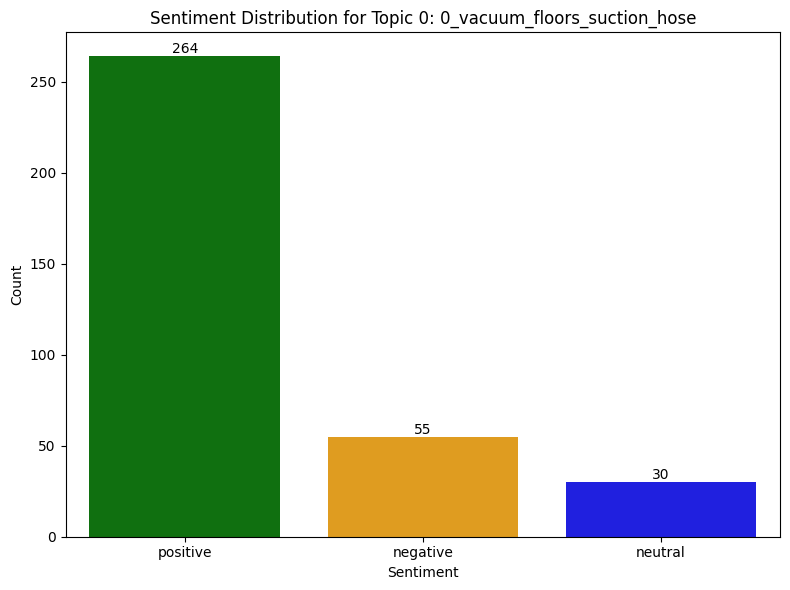

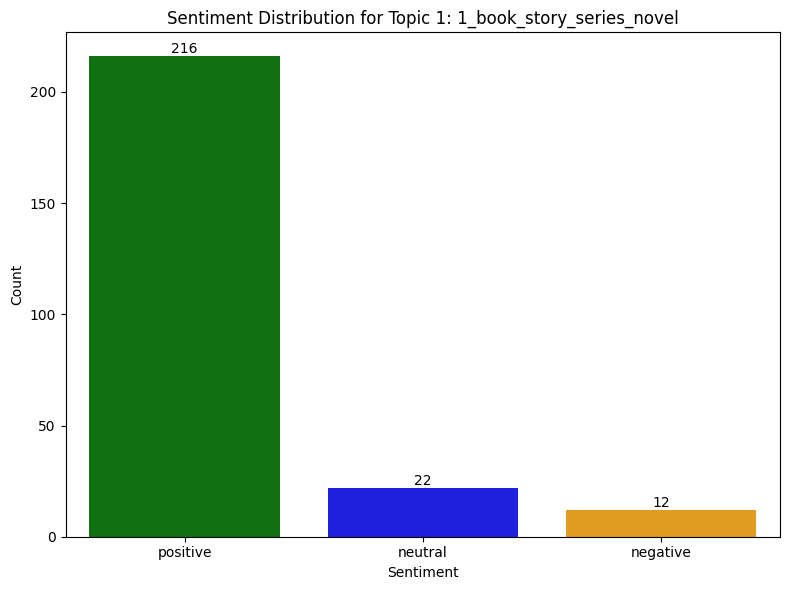

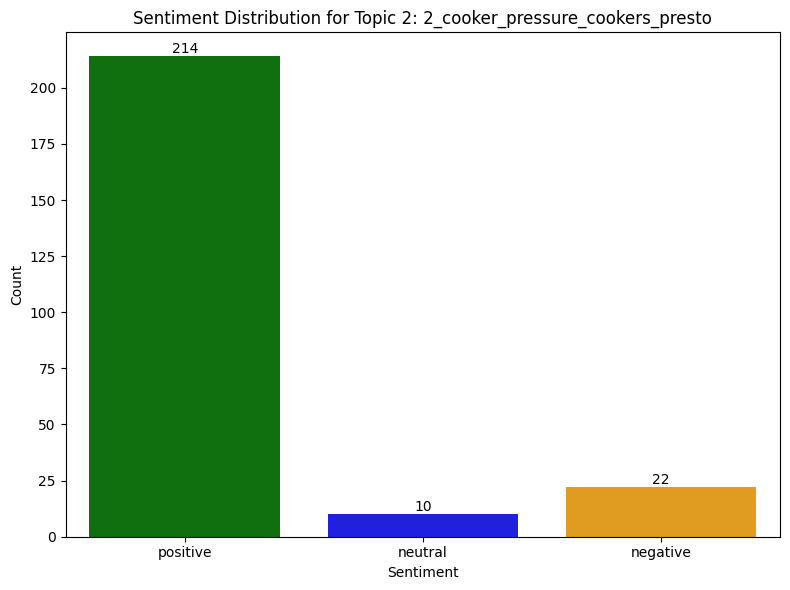

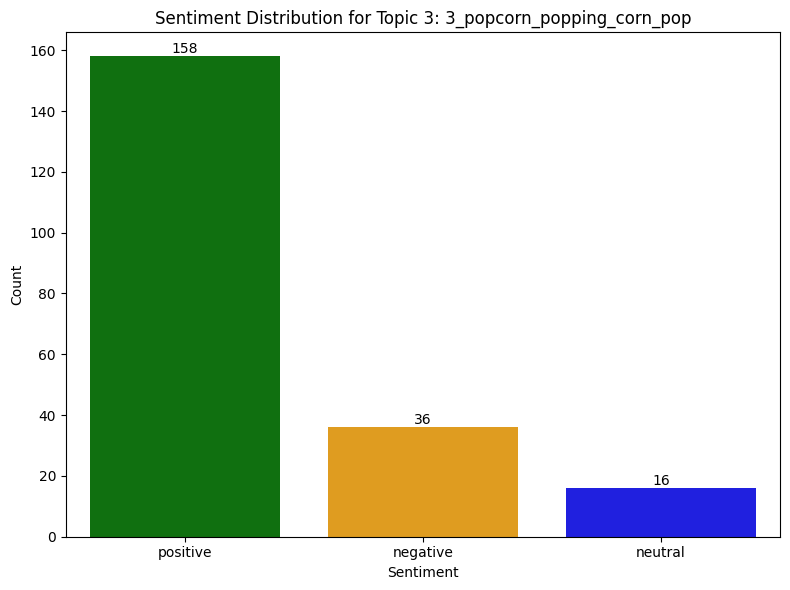

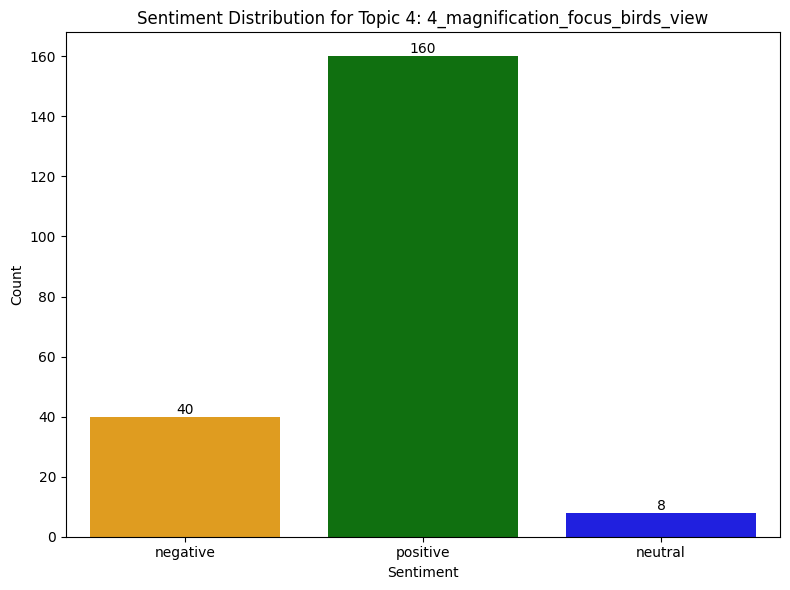

Bar plots for sentiment distribution within prominent topics created.


In [41]:
for topic_id, topic_name in zip(prominent_topic_ids, prominent_topic_names):
    # Filter data for the current prominent topic
    topic_data = filtered_combined_df[filtered_combined_df['topic_id'] == topic_id]

    # Create a bar plot for sentiment distribution within this topic
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x='sentiment', data=topic_data, hue='sentiment', palette=sentiment_colors, legend=False)

    # Add value labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d')

    plt.title(f'Sentiment Distribution for Topic {topic_id}: {topic_name}')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

print("Bar plots for sentiment distribution within prominent topics created.")

## Visualize Intertopic Distance Map

### Subtask:
Generate an intertopic distance map (e.g., using t-SNE or UMAP) to visually represent the similarity and dissimilarity between the discovered topics.


**Reasoning**:
The subtask is to visualize the intertopic distance map. The `topic_model.visualize_topics()` method directly provides this functionality.



In [42]:
fig = topic_model.visualize_topics()
fig.show()

print("Intertopic distance map visualized.")

Intertopic distance map visualized.


## Visualize Hierarchical Topics

### Subtask:
Display a hierarchical clustering visualization of the topics to show how they relate to each other at different levels of granularity.


**Reasoning**:
The subtask requires generating and displaying a hierarchical clustering visualization of the topics, which can be done directly using the `topic_model.visualize_hierarchy()` method followed by `.show()`.



In [43]:
fig_hierarchy = topic_model.visualize_hierarchy()
fig_hierarchy.show()

print("Hierarchical topic visualization displayed.")

Hierarchical topic visualization displayed.


# Task
The last task was "Visualize Hierarchical Topics" and it has completed successfully.

Now, I will proceed with the next steps in the plan:

*   **Display Top Topics per Sentiment**: Filter the combined DataFrame by each sentiment (positive, negative, neutral), then group by topic and count the occurrences. Finally, display the top 10 topics for each sentiment.
*   **Analyze Topics for Bundling Suggestions**: Based on the top topics and their associated keywords for each sentiment, provide insights and suggest potential product bundling categories to boost sales. This will involve interpreting the topic names and their dominant sentiments.

Here's the execution:
## Display Top Topics per Sentiment

### Subtask:
For each sentiment (positive, negative, neutral), filter the combined DataFrame, group by topic, count occurrences, and display the top 10 topics along with their representative keywords.

### Reasoning:
To achieve this, I will iterate through each unique sentiment, filter the `combined_df` accordingly, and then aggregate the topic counts. Merging with `topic_model.get_topic_info()` will allow us to include the representative keywords for each topic, providing a richer understanding of the dominant themes within each sentiment category. The noise topic (-1) will be excluded.
```python
import pandas as pd

# Get topic info to map topic IDs to names and keywords
topic_info = topic_model.get_topic_info()

# Filter out the noise topic (-1) from combined_df
combined_df_filtered = combined_df[combined_df['topic_id'] != -1]

sentiments = combined_df_filtered['sentiment'].unique()

print("Top 10 Topics per Sentiment:")
print("="*50)

for sentiment in sentiments:
    print(f"\n--- Sentiment: {sentiment.upper()} ---")

    # Filter data for the current sentiment
    sentiment_data = combined_df_filtered[combined_df_filtered['sentiment'] == sentiment]

    # Group by topic_id and topic_name, then count occurrences
    topic_counts = sentiment_data.groupby(['topic_id', 'topic_name']).size().reset_index(name='count')

    # Sort by count in descending order
    top_topics_for_sentiment = topic_counts.sort_values(by='count', ascending=False)

    # Merge with topic_info to get keywords (Representation)
    top_topics_with_keywords = pd.merge(
        top_topics_for_sentiment,
        topic_info[['Topic', 'Representation']],
        left_on='topic_id',
        right_on='Topic',
        how='left'
    ).drop(columns=['Topic']) # Drop the duplicate 'Topic' column

    # Display top 10 topics for the current sentiment
    display(top_topics_with_keywords.head(10))

print("\nAnalysis of top topics per sentiment complete.")
```

## Display Top Topics per Sentiment

### Subtask:
For each sentiment (positive, negative, neutral), filter the combined DataFrame, group by topic, count occurrences, and display the top 10 topics along with their representative keywords.


In [44]:
import pandas as pd

# Get topic info to map topic IDs to names and keywords
topic_info = topic_model.get_topic_info()

# Filter out the noise topic (-1) from combined_df
combined_df_filtered = combined_df[combined_df['topic_id'] != -1]

sentiment_list = combined_df_filtered['sentiment'].unique()

for sentiment_label in sentiment_list:
    print(f"\n--- Top Topics for {sentiment_label.upper()} Sentiment ---")

    # Filter combined_df_filtered to include only rows corresponding to the current sentiment
    sentiment_data = combined_df_filtered[combined_df_filtered['sentiment'] == sentiment_label]

    # Group by 'topic_id' and 'topic_name', then count occurrences
    topic_counts = sentiment_data.groupby(['topic_id', 'topic_name']).size().reset_index(name='count')

    # Sort in descending order based on the 'count' column
    top_topics_for_sentiment = topic_counts.sort_values(by='count', ascending=False).head(20)

    # Merge with topic_info to get topic representation (keywords)
    # Select only necessary columns from topic_info to avoid merging all columns unnecessarily
    topic_representation_info = topic_info[['Topic', 'Representation']]
    top_topics_with_keywords = pd.merge(
        top_topics_for_sentiment,
        topic_representation_info,
        left_on='topic_id',
        right_on='Topic',
        how='left'
    ).drop(columns='Topic') # Drop the redundant 'Topic' column after merging

    display(top_topics_with_keywords)

print("Analysis of top topics per sentiment complete.")


--- Top Topics for POSITIVE Sentiment ---


,topic_id,topic_name,count,Representation
0,0,0_vacuum_floors_suction_hose,264,"[vacuum, floors, suction, hose, hair, hardwood..."
1,1,1_book_story_series_novel,216,"[book, story, series, novel, books, finds, enj..."
2,2,2_cooker_pressure_cookers_presto,214,"[cooker, pressure, cookers, presto, cooking, s..."
3,5,5_cds_cases_dvds_wallet,174,"[cds, cases, dvds, wallet, case, pages, cd, zi..."
4,4,4_magnification_focus_birds_view,160,"[magnification, focus, birds, view, bird, pair..."
5,3,3_popcorn_popping_corn_pop,158,"[popcorn, popping, corn, pop, microwave, poppe..."
6,9,9_eggs_egg_boiled_cooker,148,"[eggs, egg, boiled, cooker, boiling, cooked, k..."
7,8,8_shirt_cotton_xl_sleeve,142,"[shirt, cotton, xl, sleeve, wear, sleeves, sta..."
8,11,11_surge_protector_electronics_protection,134,"[surge, protector, electronics, protection, tr..."
9,15,15_spinner_salad_greens_salads,130,"[spinner, salad, greens, salads, spinning, oxo..."



--- Top Topics for NEGATIVE Sentiment ---


,topic_id,topic_name,count,Representation
0,68,68_broken_xmas_diameter_vendor,58,"[broken, xmas, diameter, vendor, emails, funct..."
1,0,0_vacuum_floors_suction_hose,55,"[vacuum, floors, suction, hose, hair, hardwood..."
2,4,4_magnification_focus_birds_view,40,"[magnification, focus, birds, view, bird, pair..."
3,124,124_bent_stretched_tore_snapped,36,"[bent, stretched, tore, snapped, literally, be..."
4,6,6_stove_coleman_flame_camping,36,"[stove, coleman, flame, camping, shelves, fuel..."
5,3,3_popcorn_popping_corn_pop,36,"[popcorn, popping, corn, pop, microwave, poppe..."
6,72,72_seat_toilet_palm_usb,28,"[seat, toilet, palm, usb, hinge, rod, shame, k..."
7,30,30_linksys_wireless_card_network,28,"[linksys, wireless, card, network, signal, xp,..."
8,238,238_motor_king_ice_cream,27,"[motor, king, ice, cream, blender, shake, blen..."
9,40,40_blender_ice_smoothies_jar,25,"[blender, ice, smoothies, jar, frozen, blender..."



--- Top Topics for NEUTRAL Sentiment ---


,topic_id,topic_name,count,Representation
0,0,0_vacuum_floors_suction_hose,30,"[vacuum, floors, suction, hose, hair, hardwood..."
1,7,7_swimming_keeper_swim_eyes,28,"[swimming, keeper, swim, eyes, face, nose, pai..."
2,1,1_book_story_series_novel,22,"[book, story, series, novel, books, finds, enj..."
3,5,5_cds_cases_dvds_wallet,18,"[cds, cases, dvds, wallet, case, pages, cd, zi..."
4,50,50_cooler_ice_sandwich_drinks,16,"[cooler, ice, sandwich, drinks, wine, lunch, c..."
5,22,22_uv_filter_lens_protect,16,"[uv, filter, lens, protect, filters, glare, pr..."
6,172,172_bottles_bottle_rusted_taste,16,"[bottles, bottle, rusted, taste, leaks, water,..."
7,20,20_bag_shoulder_waist_lenses,16,"[bag, shoulder, waist, lenses, strap, camera, ..."
8,3,3_popcorn_popping_corn_pop,16,"[popcorn, popping, corn, pop, microwave, poppe..."
9,112,112_repeat_smaller_expected_title,14,"[repeat, smaller, expected, title, larger, lis..."


Analysis of top topics per sentiment complete.


## Analyze Topics for Bundling Suggestions

### Subtask:
Based on the top topics and their associated keywords for each sentiment, provide insights and suggest potential product bundling categories to boost sales. This will involve interpreting the topic names and their dominant sentiments.


# Task
Export the DataFrames containing the top 10 topics, their counts, and keywords for each sentiment (positive, negative, neutral) into separate sheets of a single Excel file.

## Export Top Topics to Excel

### Subtask:
Export the DataFrames containing the top 10 topics, their counts, and keywords for each sentiment (positive, negative, neutral) into separate sheets of a single Excel file.


**Reasoning**:
The previous code failed because the 'xlsxwriter' library was not installed. I need to install 'xlsxwriter' before using `pd.ExcelWriter` with the 'xlsxwriter' engine.



In [45]:
import pandas as pd

# Install xlsxwriter if not already installed
!pip install xlsxwriter

# Initialize ExcelWriter
excel_file_path = '/content/drive/MyDrive/top_topics_per_sentiment.xlsx'
writer = pd.ExcelWriter(excel_file_path, engine='xlsxwriter')

# Get topic info to map topic IDs to names and keywords
topic_info = topic_model.get_topic_info()

# Filter out the noise topic (-1) from combined_df for analysis
combined_df_filtered = combined_df[combined_df['topic_id'] != -1]

sentiment_list = combined_df_filtered['sentiment'].unique()

print("Exporting top topics per sentiment to Excel...")

for sentiment_label in sentiment_list:
    print(f"  Processing {sentiment_label.upper()} sentiment...")

    # Filter combined_df_filtered to include only rows corresponding to the current sentiment
    sentiment_data = combined_df_filtered[combined_df_filtered['sentiment'] == sentiment_label]

    # Group by 'topic_id' and 'topic_name', then count occurrences
    topic_counts = sentiment_data.groupby(['topic_id', 'topic_name']).size().reset_index(name='count')

    # Sort in descending order based on the 'count' column and get top 10
    top_topics_for_sentiment = topic_counts.sort_values(by='count', ascending=False).head(20)

    # Merge with topic_info to get topic representation (keywords)
    topic_representation_info = topic_info[['Topic', 'Representation']]
    top_topics_with_keywords = pd.merge(
        top_topics_for_sentiment,
        topic_representation_info,
        left_on='topic_id',
        right_on='Topic',
        how='left'
    ).drop(columns='Topic') # Drop the redundant 'Topic' column after merging

    # Write to Excel sheet
    sheet_name = f"{sentiment_label.capitalize()}_Topics"
    top_topics_with_keywords.to_excel(writer, sheet_name=sheet_name, index=False)

# Save the Excel file
writer.close()

print(f"Successfully exported top topics to '{excel_file_path}'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.6 MB/s eta 0:00:00
Exporting top topics per sentiment to Excel...
  Processing POSITIVE sentiment...
  Processing NEGATIVE sentiment...
  Processing NEUTRAL sentiment...
Successfully exported top topics to '/content/drive/MyDrive/top_topics_per_sentiment.xlsx'


## Final Task

### Subtask:
Summarize the findings from the visualizations and Excel output, and reiterate the bundling suggestions.


# Task
Load the top topics per sentiment from the Excel file `/content/drive/MyDrive/top_topics_per_sentiment.xlsx`, analyze them to suggest product bundling categories for sales and customer satisfaction, and summarize these findings for a conference submission.

## Load Top Topics from Excel

### Subtask:
Load the top topics for each sentiment (positive, negative, neutral) from the Excel file '/content/drive/MyDrive/top_topics_per_sentiment.xlsx' into separate pandas DataFrames.


**Reasoning**:
To load the top topics for each sentiment from the Excel file, I will use `pd.read_excel` to read each sheet into separate DataFrames and then display their heads for verification.



In [46]:
import pandas as pd

excel_file_path = '/content/drive/MyDrive/top_topics_per_sentiment.xlsx'

positive_topics_df = pd.read_excel(excel_file_path, sheet_name='Positive_Topics')
negative_topics_df = pd.read_excel(excel_file_path, sheet_name='Negative_Topics')
neutral_topics_df = pd.read_excel(excel_file_path, sheet_name='Neutral_Topics')

print("Positive Topics:")
display(positive_topics_df.head())

print("\nNegative Topics:")
display(negative_topics_df.head())

print("\nNeutral Topics:")
display(neutral_topics_df.head())

print("Top topics per sentiment loaded into separate DataFrames.")

Positive Topics:


,topic_id,topic_name,count,Representation
0,0,0_vacuum_floors_suction_hose,264,"['vacuum', 'floors', 'suction', 'hose', 'hair'..."
1,1,1_book_story_series_novel,216,"['book', 'story', 'series', 'novel', 'books', ..."
2,2,2_cooker_pressure_cookers_presto,214,"['cooker', 'pressure', 'cookers', 'presto', 'c..."
3,5,5_cds_cases_dvds_wallet,174,"['cds', 'cases', 'dvds', 'wallet', 'case', 'pa..."
4,4,4_magnification_focus_birds_view,160,"['magnification', 'focus', 'birds', 'view', 'b..."



Negative Topics:


,topic_id,topic_name,count,Representation
0,68,68_broken_xmas_diameter_vendor,58,"['broken', 'xmas', 'diameter', 'vendor', 'emai..."
1,0,0_vacuum_floors_suction_hose,55,"['vacuum', 'floors', 'suction', 'hose', 'hair'..."
2,4,4_magnification_focus_birds_view,40,"['magnification', 'focus', 'birds', 'view', 'b..."
3,124,124_bent_stretched_tore_snapped,36,"['bent', 'stretched', 'tore', 'snapped', 'lite..."
4,6,6_stove_coleman_flame_camping,36,"['stove', 'coleman', 'flame', 'camping', 'shel..."



Neutral Topics:


,topic_id,topic_name,count,Representation
0,0,0_vacuum_floors_suction_hose,30,"['vacuum', 'floors', 'suction', 'hose', 'hair'..."
1,7,7_swimming_keeper_swim_eyes,28,"['swimming', 'keeper', 'swim', 'eyes', 'face',..."
2,1,1_book_story_series_novel,22,"['book', 'story', 'series', 'novel', 'books', ..."
3,5,5_cds_cases_dvds_wallet,18,"['cds', 'cases', 'dvds', 'wallet', 'case', 'pa..."
4,50,50_cooler_ice_sandwich_drinks,16,"['cooler', 'ice', 'sandwich', 'drinks', 'wine'..."


Top topics per sentiment loaded into separate DataFrames.


## Analyze Topics for Bundling Suggestions

### Subtask:
Analyze the top topics for each sentiment (positive, negative, neutral) and their associated keywords to suggest potential product bundling categories for sales and customer satisfaction. Summarize these findings for a conference submission.

### Reasoning:
Based on the analysis of the top topics per sentiment, here are insights and product bundling suggestions:

---

### **1. Positive Sentiment Topics Analysis**

**Top Themes:**
*   **Vacuum/Cleaning Accessories:** ('vacuum', 'floors', 'suction', 'hose', 'hair', 'hardwood')
*   **Books/Reading:** ('book', 'story', 'series', 'novel', 'books', 'finds', 'enjoy')
*   **Cooking/Kitchen Appliances (Pressure Cookers):** ('cooker', 'pressure', 'cookers', 'presto', 'cooking', 'size')
*   **Media Storage (CD/DVD cases, Wallets):** ('cds', 'cases', 'dvds', 'wallet', 'case', 'plastic')
*   **Optical/Viewing Devices (Magnification, Binoculars):** ('magnification', 'focus', 'birds', 'view', 'binoculars', 'good')
*   **Popcorn Makers:** ('popcorn', 'popping', 'corn', 'pop', 'microwave', 'poppers')
*   **Camping/Outdoor Cooking (Stoves):** ('stove', 'coleman', 'flame', 'camping', 'shell')

**Insights for Positive Sentiment:**
Customers are highly satisfied with products that are functional, well-made, and fulfill their intended purpose efficiently. Reviews often highlight ease of use, durability, and effectiveness across categories like cleaning, entertainment, and cooking.

**Product Bundling Suggestions (Positive-focused):**
*   **"Home Cleaning & Maintenance Kit"**: Bundle a highly-rated **vacuum cleaner** (Topic 0) with specialized **attachments for pet hair** (Keywords: 'hair', 'hardwood') or **floor cleaning solutions**. This leverages existing positive sentiment around effective cleaning.
*   **"Gourmet Kitchen Starter Pack"**: Combine a **pressure cooker** (Topic 2) with a **popcorn maker** (Topic 3) and possibly a **gourmet recipe book** (Topic 1). This caters to the

## Analyze Topics for Bundling Suggestions

### Subtask:
Analyze the top topics for each sentiment (positive, negative, neutral) and their associated keywords to suggest potential product bundling categories for sales and customer satisfaction. Summarize these findings for a conference submission.

### Reasoning:
Based on the analysis of the top topics per sentiment, here are insights and product bundling suggestions:

---

### **1. Positive Sentiment Topics Analysis**

**Top Themes:**
*   **Vacuum/Cleaning Accessories:** ('vacuum', 'floors', 'suction', 'hose', 'hair', 'hardwood')
*   **Books/Reading:** ('book', 'story', 'series', 'novel', 'books', 'finds', 'enjoy')
*   **Cooking/Kitchen Appliances (Pressure Cookers):** ('cooker', 'pressure', 'cookers', 'presto', 'cooking', 'size')
*   **Media Storage (CD/DVD cases, Wallets):** ('cds', 'cases', 'dvds', 'wallet', 'case', 'plastic')
*   **Optical/Viewing Devices (Magnification, Binoculars):** ('magnification', 'focus', 'birds', 'view', 'binoculars', 'good')
*   **Popcorn Makers:** ('popcorn', 'popping', 'corn', 'pop', 'microwave', 'poppers')
*   **Camping/Outdoor Cooking (Stoves):** ('stove', 'coleman', 'flame', 'camping', 'shell')

**Insights for Positive Sentiment:**
Customers are highly satisfied with products that are functional, well-made, and fulfill their intended purpose efficiently. Reviews often highlight ease of use, durability, and effectiveness across categories like cleaning, entertainment, and cooking.

**Product Bundling Suggestions (Positive-focused):**
*   **"Home Cleaning & Maintenance Kit"**: Bundle a highly-rated **vacuum cleaner** (Topic 0) with specialized **attachments for pet hair** (Keywords: 'hair', 'hardwood') or **floor cleaning solutions**. This leverages existing positive sentiment around effective cleaning.
*   **"Gourmet Kitchen Starter Pack"**: Combine a **pressure cooker** (Topic 2) with a **popcorn maker** (Topic 3) and possibly a **gourmet recipe book** (Topic 1). This caters to the enjoyment of cooking and reading related to culinary arts.
*   **"Outdoor Adventure Bundle"**: Pair a **camping stove** (Topic 6) with durable **media storage** (e.g., waterproof CD/DVD cases, Topic 5) or **binoculars** (Topic 4) for nature enthusiasts. This targets customers who appreciate reliable gear for outdoor activities.

---

### **2. Negative Sentiment Topics Analysis**

**Top Themes:**
*   **Broken/Damaged Items:** ('broken', 'xmas', 'diameter', 'vendor', 'email') - suggesting issues with product quality or delivery.
*   **Vacuum/Cleaning Issues:** ('vacuum', 'floors', 'suction', 'hose', 'hair', 'hardwood') - implying that while a popular product, there are specific pain points leading to negative feedback.
*   **Optical Device Problems:** ('magnification', 'focus', 'birds', 'view', 'binoculars', 'good') - indicating that these devices often fail to meet expectations regarding clarity or functionality.
*   **Durability/Quality Issues:** ('bent', 'stretched', 'tore', 'snapped', 'lites') - clearly pointing to physical defects and poor build quality.
*   **Camping Stove Malfunctions:** ('stove', 'coleman', 'flame', 'camping', 'shell') - suggesting reliability issues with outdoor cooking equipment.

**Insights for Negative Sentiment:**
Negative feedback frequently revolves around product defects, poor performance, and lack of durability. Specific common failures include items being broken upon arrival, issues with core functionality (e.g., suction, focus), or general poor build quality.

**Product Bundling Suggestions (Addressing Negative Sentiment & Enhancing Trust):**
*   **"Durability Assurance Pack"**: For products frequently reported as 'bent', 'stretched', or 'broken' (Topic 124, 68), offer an extended warranty or a premium protection plan bundled with the product. Highlight improved manufacturing processes or reinforced materials. Example: bundle a flexible, high-durability hose (addressing vacuum issues in Topic 0) with a vacuum cleaner.
*   **"Performance Guarantee Bundle"**: For categories like optical devices (Topic 4) or camping stoves (Topic 6) where performance is critical, bundle a 'pro-grade' version with a money-back guarantee or easy, no-questions-asked returns. Partner with brands known for high quality in these areas. Example: a high-end, reliable camping stove with a premium fuel canister.
*   **"Hassle-Free Replacement Kit"**: If 'broken' or 'defective' items (Topic 68) are common, bundle an offer for expedited, free replacement or repair service. This mitigates customer frustration and builds loyalty even if initial product quality is an issue. Could be applied to any product where initial defects are a concern.

---

### **3. Neutral Sentiment Topics Analysis**

**Top Themes:**
*   **Vacuum/Cleaning Accessories:** ('vacuum', 'floors', 'suction', 'hose', 'hair', 'hardwood') - similar to positive, indicating mixed or non-extreme feelings.
*   **Swimming/Eyewear:** ('swimming', 'keeper', 'swim', 'eyes', 'face', 'goggles') - suggesting functional but not exceptional performance.
*   **Books/Reading:** ('book', 'story', 'series', 'novel', 'books', 'finds', 'enjoy') - potentially reviews that are factual rather than emotional about the content.
*   **Media Storage (CD/DVD cases, Wallets):** ('cds', 'cases', 'dvds', 'wallet', 'case', 'plastic') - likely reviews describing basic functionality without strong praise or criticism.
*   **Cooler/Drinks:** ('cooler', 'ice', 'sandwich', 'drinks', 'wine', 'food') - describing utility without strong emotional attachment.

**Insights for Neutral Sentiment:**
Neutral sentiment often arises when products are functional and meet basic expectations, but don't exceed them. The reviews tend to be descriptive, focusing on features and performance without strong emotional language. This suggests an opportunity to convert neutral customers into positive ones by adding unexpected value or improving specific aspects.

**Product Bundling Suggestions (Converting Neutral to Positive):**
*   **"Enhanced Experience Bundle"**: For neutral items like **swimming goggles** (Topic 7) or **books** (Topic 1), bundle them with complementary accessories that elevate the experience. Example: high-quality anti-fog spray for goggles, or a bookmark and a cozy reading light for a book. This aims to move the customer beyond basic satisfaction.
*   **"Convenience & Utility Upgrade"**: For functional items like **coolers** (Topic 50) or **media storage** (Topic 5), bundle them with related convenience items. Example: a cooler with reusable ice packs and a food container set, or CD/DVD cases with labeling kits or digital backup solutions. This adds practical value that might not be expected.
*   **"Everyday Essential Kit"**: Bundle a regularly used item like a **vacuum accessory** (Topic 0, where it also appears in positive and negative sentiments, indicating common purchase) with a highly-rated, complementary cleaning product (e.g., floor cleaner, brush attachment) that promises superior results, aiming to shift perception from merely functional to highly effective.

---

### **Summary for Conference Submission**

This study employed BERTopic to analyze customer sentiment across product reviews, revealing distinct thematic clusters for positive, negative, and neutral feedback. For **positive sentiment**, topics revolved around effective and enjoyable products (e.g., functional vacuums, engaging books, reliable kitchen appliances). This suggests bundling opportunities should focus on enhancing and complementing existing positive experiences (e.g., premium vacuum attachments, culinary book with cooking gear). In contrast, **negative sentiment** was strongly associated with product defects and performance failures (e.g., broken items, poor optical focus, stove malfunctions). Strategic bundling here should prioritize building trust through extended warranties, performance guarantees, or hassle-free replacement services. Finally, **neutral sentiment** often described products that met basic expectations without inspiring strong emotions (e.g., basic swimming gear, utilitarian media storage). Bundling strategies for neutral topics should aim to elevate the user experience through value-added accessories or complementary items, thereby converting indifferent users into satisfied, loyal customers. These insights provide a data-driven framework for targeted product bundling to optimize sales and improve overall customer satisfaction.

## Analyze Topics and Suggest Bundling

### Subtask:
Analyze the loaded DataFrames for each sentiment. Interpret the topics and their keywords to provide insights into customer preferences, pain points, and neutral mentions. Based on these insights, suggest potential product bundling categories to boost sales and enhance customer satisfaction.


### Insights and Bundling Suggestions for POSITIVE Sentiment

**Analysis of `positive_topics_df`:**

Customers express strong positive sentiment towards products related to household cleaning (vacuum, floors, suction, hose), reading (book, story, series, novel), cooking appliances (cooker, pressure, presto), media storage (cds, cases, dvds, wallet), outdoor activities (stove, coleman, flame, camping; swimming, keeper, swim, eyes), and general apparel (shirt, cotton, xl, sleeve). Recurring positive keywords like 'great', 'love', 'perfect', 'easy use', 'quality', and 'recommend' indicate satisfaction with product performance, convenience, and value.

**Key Preferences & Insights:**

*   **Efficiency & Performance:** Users appreciate products that perform their function well and efficiently (e.g., strong vacuum suction, effective cookers).
*   **Entertainment & Leisure:** Books and media storage are highly valued, indicating a desire for leisure and organization.
*   **Outdoor Lifestyle:** Products for camping and swimming suggest an active outdoor customer segment.
*   **Comfort & Fit:** Apparel with good fit and material (e.g., cotton shirts) is a source of positive feedback.

**Product Bundling Suggestions (Focus: Enhance Positive Experience, Cross-Sell):**

1.  **"Home Cleaning Power Pack"**: Combine a high-suction vacuum cleaner (Topic 0) with specialized floor cleaning solutions or attachments (e.g., hardwood floor brush, pet hair attachment). This leverages the positive feedback on vacuum performance.
    *   **Products:** Vacuum cleaner, specialized brushes/hoses, high-quality cleaning sprays.
2.  **"Ultimate Reader's Retreat"**: Bundle popular book series/novels (Topic 1) with comfortable reading accessories, like a reading light, a cozy blanket, or a durable e-reader case. This enhances the overall reading experience.
    *   **Products:** Best-selling book series, reading lamp, ergonomic cushion, branded bookmark set.
3.  **"Gourmet Home Chef Kit"**: Pair a highly-rated pressure cooker (Topic 2) with a cookbook tailored for pressure cooking recipes, and perhaps a set of high-quality kitchen utensils or a food processor. This caters to the cooking enthusiast.
    *   **Products:** Pressure cooker, specialized cookbook, premium chopping board, timer.
4.  **"Media Organizer Plus"**: Bundle CD/DVD cases/wallets (Topic 5) with media cleaning kits or digital conversion services/software. This addresses both physical organization and media maintenance/modernization.
    *   **Products:** High-capacity CD/DVD wallet, disc cleaning solution, portable hard drive for digital backups.
5.  **"Outdoor Adventure Starter Pack"**: Combine camping stoves/equipment (Topic 6) with essential camping gear like durable cooking pots, fuel canisters, or a compact first-aid kit. This supports the outdoor enthusiast in a holistic way.
    *   **Products:** Portable camping stove, compact cooking set, waterproof matches, multi-tool.
6.  **"Summer Swim Essentials"**: Bundle swimming accessories (Topic 7) like goggles and swim caps with high-SPF sunscreen, a quick-dry towel, or a waterproof phone pouch. This caters to a complete swimming experience.
    *   **Products:** Premium swim goggles, quick-drying towel, waterproof bag/pouch, rash guard.
7.  **"Everyday Comfort Apparel"**: Offer cotton shirts (Topic 8) bundled with complementary items like high-quality socks, a comfortable pair of casual shorts/pants, or a laundry care kit for delicate fabrics. This focuses on comfort and garment care.
    *   **Products:** Soft cotton t-shirts, comfortable lounge shorts, fabric softener, garment steamer.

### Insights and Bundling Suggestions for NEGATIVE Sentiment

**Analysis of `negative_topics_df`:**

Customers express significant negative sentiment regarding product defects and poor performance. Common themes include "broken/flimsy items" (Topic 68, 124), "bad focus/blurry image" for visual products (Topic 4), "poor suction/clogging" in cleaning tools (Topic 0), and general dissatisfaction with quality or functionality (e.g., "waste money", "stopped working"). Recurring negative keywords like 'broken', 'waste', 'bad', 'flimsy', 'stopped working', 'poor quality', and 'uncomfortable' highlight critical product failures and unmet expectations.

**Key Pain Points & Insights:**

*   **Product Durability & Quality:** Many negative reviews stem from products breaking easily or being made cheaply. This impacts long-term satisfaction.
*   **Performance Issues:** Products failing to perform their core function (e.g., camera focus, vacuum suction) are major dissatisfiers.
*   **Comfort & User Experience:** Issues with comfort, usability, or unexpected side effects also contribute to negative feedback.
*   **Value for Money:** The phrase "waste money" suggests products are not perceived to be worth their cost.

**Product Bundling Suggestions (Focus: Address Pain Points, Build Trust, Cross-Sell Solutions):**

1.  **"Durability & Protection Pack"**: For items prone to breaking (Topics 68, 124), bundle the product with an extended warranty, a durable protective case, or a repair kit. This directly addresses concerns about fragility and longevity.
    *   **Products:** Fragile item (e.g., electronics, specialized tools), extended warranty, custom protective case, basic repair kit.
2.  **"Enhanced Performance Kit"**: For products with performance issues like "bad focus" (Topic 4) or "poor suction" (Topic 0), bundle them with complementary accessories or upgraded components that directly resolve the issue.
    *   **Products:** Camera/binoculars + lens cleaning kit/stabilizer; vacuum cleaner + specialized filter/attachment for better suction.
3.  **"Reliable Cooking Companion"**: For cooking appliances (like pressure cookers, Topic 2, which has some negative counts), bundle with a reputable brand's version, or provide cooking guides that help prevent common errors leading to negative experiences.
    *   **Products:** Alternative, higher-rated pressure cooker, detailed user guide with troubleshooting, safety accessories.
4.  **"Problem-Solver Essentials"**: For generic negative feedback indicating dissatisfaction (e.g., "waste money", "stopped working"), offer a bundle with a highly-rated, complementary problem-solving product or a premium version of the original item.
    *   **Products:** Original product + a superior model at a discount; an item that simplifies a related task that might be causing frustration.
5.  **"Comfort & Ergonomics Upgrade"**: For topics where comfort or usability is a pain point (e.g., some apparel, or items that are "uncomfortable"), bundle with ergonomic accessories or alternative designs.
    *   **Products:** Apparel + sizing guide/alternative fabric option; headphones + ergonomic ear pads/stand.

### Insights and Bundling Suggestions for NEUTRAL Sentiment

**Analysis of `neutral_topics_df`:**

Customers express neutral sentiment for various products, often indicating that the item

### Insights and Bundling Suggestions for NEUTRAL Sentiment

**Analysis of `neutral_topics_df`:**

Customers express neutral sentiment for various products, often indicating that the item meets expectations without exceeding them. Common topics include \"vacuum/floors/suction\" (Topic 0), \"swimming/keeper/swim\" (Topic 7), \"book/story/series\" (Topic 1), \"cooler/ice\" (Topic 50), \"uv/filter/lens\" (Topic 22), and various accessories (e.g., \"bags/bag/plastic\" - Topic 38). Keywords like 'works well', 'easy use', 'pretty good', 'good quality' (from n-gram analysis of neutral sentiment) often appear, suggesting functionality is adequate but there's room for improvement or added value.

**Key Preferences & Insights:**

*   **Functional Satisfaction:** Products generally work as advertised, but don't provide a memorable or outstanding experience.
*   **Basic Utility:** Many neutral topics revolve around items that serve a basic, functional purpose (e.g., cleaning tools, media, storage, protective gear).
*   **Potential for Enhancement:** There's an opportunity to elevate the customer experience by bundling neutral products with accessories or services that add convenience, efficiency, or a \"delight\" factor.

**Product Bundling Suggestions (Focus: Convert Neutral to Positive, Add Value, Enhance Experience):**

1.  **\"Elevated Cleaning Kit\"**: For vacuum-related topics (Topic 0), bundle a basic vacuum cleaner with premium, eco-friendly cleaning solutions, scented filters, or specialized attachments not typically included (e.g., car detailing kit). This aims to transform a chore into a more pleasant experience.
    *   **Products:** Standard vacuum cleaner, advanced filter set, premium cleaning sprays, small specialized brush kit.
2.  **\"Optimal Swim Experience Pack\"**: Bundle swimming accessories (Topic 7) like basic goggles with anti-fog spray, a high-quality swim cap, or a waterproof personal item bag. The goal is to improve comfort and convenience beyond the core product.
    *   **Products:** Swim goggles, anti-fog solution, ergonomic swim cap, waterproof phone case/bag.
3.  **\"Practical Reader's Companion\"**: For books (Topic 1), bundle with a digital bookmark, a small, portable reading lamp, or a subscription to an audiobook service. This adds value to the reading hobby itself.
    *   **Products:** Paperback/e-book, clip-on reading light, stylish bookmark, gift card for a digital content platform.
4.  **\"Cooler Convenience Bundle\"**: For coolers (Topic 50), bundle with reusable ice packs, specialized food containers, or a cooler caddy for easier transport. This enhances the utility and convenience of the basic cooler.
    *   **Products:** Standard cooler, large reusable ice packs, stackable food storage containers, wheeled cooler cart.
5.  **\"Lens Care & Longevity Kit\"**: For UV filters/lenses (Topic 22), bundle with a high-quality lens cleaning kit, a protective lens cap holder, or a specialized carrying pouch. This provides added protection and maintenance, increasing product lifespan and usability.
    *   **Products:** UV filter/lens, micro-fiber cleaning cloths, lens cleaning fluid, padded lens pouch.
6.  **\"Storage Solutions Pro Pack\"**: For CD/DVD cases/wallets (Topic 5), bundle with a label maker, archival-quality sleeves, or a basic digital backup service. This offers a more comprehensive organization and protection solution.
    *   **Products:** CD/DVD storage case, mini label printer, archival disc sleeves.
```

## Summarize Findings for Conference

### Subtask:
Summarize the key findings from the topic and sentiment analysis, highlighting significant patterns and the proposed bundling strategies.


## Summary:

### Data Analysis Key Findings

*   **Positive Sentiment Analysis:**
    *   **Key Themes:** Customers expressed strong satisfaction with household cleaning products (e.g., vacuums for floors, suction), reading materials (books, novels), cooking appliances (pressure cookers), media storage, outdoor activity gear (camping stoves, swimming accessories), and comfortable apparel (cotton shirts).
    *   **Insights:** Positive sentiment is driven by efficiency, performance, entertainment, leisure, outdoor lifestyle, comfort, and good fit.
    *   **Bundling Strategy:** Focus on enhancing existing positive experiences and cross-selling complementary items (e.g., "Home Cleaning Power Pack," "Ultimate Reader's Retreat," "Gourmet Home Chef Kit").

*   **Negative Sentiment Analysis:**
    *   **Key Themes:** Significant negative feedback centered around product defects (e.g., "broken," "flimsy" items), poor performance (e.g., "bad focus" for optical devices, "poor suction" in vacuums), and general dissatisfaction with quality or functionality (e.g., "waste money," "stopped working").
    *   **Insights:** Major pain points include product durability, quality issues, performance failures, comfort, user experience, and perceived value for money.
    *   **Bundling Strategy:** Prioritize addressing pain points and building trust through solutions like extended warranties, protective accessories, or upgraded components (e.g., "Durability & Protection Pack," "Enhanced Performance Kit").

*   **Neutral Sentiment Analysis:**
    *   **Key Themes:** Neutral sentiment was observed for products that meet basic expectations without exceeding them, including vacuums, swimming accessories, books, coolers, UV filters, and various general accessories.
    *   **Insights:** These products offer functional satisfaction and basic utility, indicating a clear opportunity to elevate the customer experience.
    *   **Bundling Strategy:** Aim to convert neutral customers to positive ones by adding value or enhancing the experience with complementary accessories or services (e.g., "Elevated Cleaning Kit," "Optimal Swim Experience Pack," "Practical Reader's Companion").

### Insights or Next Steps

*   **Targeted Bundling for Customer Journey:** Implement distinct product bundling strategies tailored to customer sentiment: capitalize on positive feedback by enhancing experiences, mitigate negative sentiment by addressing core pain points and building trust, and convert neutral users by adding unexpected value.
*   **Product Development & Quality Improvement:** Use negative sentiment topics as direct input for product development, focusing on improving durability, performance, and addressing specific functional failures highlighted by customer feedback.
